# Data provisioning

#### Previous notebook: [Data collection](01_data_collection.ipynb)

## Split labels into separate columns
In the original disaster response dataset all labels per message are stored as a single string in the *categories* column, separated by semicolons. In this step, I split the labels into different columns, one per label. This is done to ensure the data is stored in a suitable format for converting each label values into numeric data type:

In [53]:
import pandas as pd

df_raw = pd.read_csv("../data/raw/disaster_dataset.csv")
cats_expanded = df_raw["categories"].str.split(";", expand=True)
row = cats_expanded.iloc[0]
category_colnames = row.apply(lambda x: x.split("-")[0])
cats_expanded.columns = category_colnames
cats_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26144 entries, 0 to 26143
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   related                 26144 non-null  object
 1   request                 26144 non-null  object
 2   offer                   26144 non-null  object
 3   aid_related             26144 non-null  object
 4   medical_help            26144 non-null  object
 5   medical_products        26144 non-null  object
 6   search_and_rescue       26144 non-null  object
 7   security                26144 non-null  object
 8   military                26144 non-null  object
 9   child_alone             26144 non-null  object
 10  water                   26144 non-null  object
 11  food                    26144 non-null  object
 12  shelter                 26144 non-null  object
 13  clothing                26144 non-null  object
 14  money                   26144 non-null  object
 15  mi

In [54]:
cats_expanded.head()

,related,request,offer,aid_related,medical_help,medical_products,search_and_rescue,security,military,child_alone,...,aid_centers,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report
0,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
1,related-1,request-0,offer-0,aid_related-1,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-1,floods-0,storm-1,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
2,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
3,related-1,request-1,offer-0,aid_related-1,medical_help-0,medical_products-1,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0
4,related-1,request-0,offer-0,aid_related-0,medical_help-0,medical_products-0,search_and_rescue-0,security-0,military-0,child_alone-0,...,aid_centers-0,other_infrastructure-0,weather_related-0,floods-0,storm-0,fire-0,earthquake-0,cold-0,other_weather-0,direct_report-0


As we can see from the output above, the categories column is now separated into 36 label-based columns. Each column stores the name of the label and a number that represents whether the label applies to the message (1) or not (0). This ensures all labels were properly separated as their current count equals the original dataset documentation.

## Convert columns to numeric values
In this step, I go through all *label - number* values, remove the text, keep only the numeric value and cast it into an integer. Finally, I check the labels' data types, to ensure they are correctly stored and suitable to be used as target variables:

In [55]:
for col in category_colnames:
    cats_expanded[col] = cats_expanded[col].str.split("-").str[-1].astype(int)

df_raw = df_raw.drop(columns=["categories"])
df_raw = pd.concat([df_raw, cats_expanded], axis=1)
df_raw.to_csv("../data/raw/dd_raw_sep_labels.csv", index=False)
cats_expanded.dtypes

0
related                   int64
request                   int64
offer                     int64
aid_related               int64
medical_help              int64
medical_products          int64
search_and_rescue         int64
security                  int64
military                  int64
child_alone               int64
water                     int64
food                      int64
shelter                   int64
clothing                  int64
money                     int64
missing_people            int64
refugees                  int64
death                     int64
other_aid                 int64
infrastructure_related    int64
transport                 int64
buildings                 int64
electricity               int64
tools                     int64
hospitals                 int64
shops                     int64
aid_centers               int64
other_infrastructure      int64
weather_related           int64
floods                    int64
storm                     int64
fire  

## Check all unique values per column
After converting all column values to integers, I will go through all category columns, and store all unique values per label to verify whether the columns contain only binary values (1 and 0):

In [56]:
binary_check = {}

for col in cats_expanded.columns:
    vals = sorted(cats_expanded[col].unique().tolist())
    binary_check[col] = vals

binary_check

{'related': [0, 1, 2],
 'request': [0, 1],
 'offer': [0, 1],
 'aid_related': [0, 1],
 'medical_help': [0, 1],
 'medical_products': [0, 1],
 'search_and_rescue': [0, 1],
 'security': [0, 1],
 'military': [0, 1],
 'child_alone': [0],
 'water': [0, 1],
 'food': [0, 1],
 'shelter': [0, 1],
 'clothing': [0, 1],
 'money': [0, 1],
 'missing_people': [0, 1],
 'refugees': [0, 1],
 'death': [0, 1],
 'other_aid': [0, 1],
 'infrastructure_related': [0, 1],
 'transport': [0, 1],
 'buildings': [0, 1],
 'electricity': [0, 1],
 'tools': [0, 1],
 'hospitals': [0, 1],
 'shops': [0, 1],
 'aid_centers': [0, 1],
 'other_infrastructure': [0, 1],
 'weather_related': [0, 1],
 'floods': [0, 1],
 'storm': [0, 1],
 'fire': [0, 1],
 'earthquake': [0, 1],
 'cold': [0, 1],
 'other_weather': [0, 1],
 'direct_report': [0, 1]}

As we can see from the results above, the most columns contain binary values, except for the *related* one which consists of the numbers 0,1 and 2. Additionally, we can see that the *child_alone* column only consists of 0, which is a clear indication that this label will be removed later as it does not apply to any of the messages and does not bring any valuable information for the training stage.

In the original dataset documentation, it is mentioned that the 2s in the column *related* represent the answer "unsure" for messages that cannot be clearly categorized. Due to the sensitivity of the child-related messages and the potential risk of developing a model that could identify at-risk minors all *child_alone* annotations are 0.

## Problem-defining feature engineering
In this step, I will transform the 36 labels from the disaster dataset into a smaller problem-oriented set that matches the original goal of my project - to detect what kind of help is required in each message. Additionally, I decided to add the "people_satus" label, as it could bring valuable information and help with prioritization:

In [57]:
df = df_raw.copy()
df["need_basic_supplies"] = ((df["food"]==1) | (df["water"]==1) | (df["clothing"]==1)).astype(int)
df["need_medical_help"] = ((df["medical_help"]==1) | (df["medical_products"]==1) | (df["hospitals"]==1)).astype(int)
df["need_safety_rescue"] = ((df["security"]==1) | (df["military"]==1) | (df["search_and_rescue"]==1)).astype(int)
df["need_shelter"] = df["shelter"].copy()
df["people_status"] = ((df["missing_people"]==1) | (df["death"]==1) | (df["refugees"]==1)).astype(int)
df = df.drop(columns=cats_expanded.columns)
df.head()

,id,message,original,genre,need_basic_supplies,need_medical_help,need_safety_rescue,need_shelter,people_status
0,2,Weather update - a cold front from Cuba that could pass over Haiti,Un front froid se retrouve sur Cuba ce matin. Il pourrait traverser Haiti demain. Des averses de pluie isolee sont encore prevues sur notre region ce soi,direct,0,0,0,0,0
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,0,0,0,0,0
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ak timoun yo. Mesi se john jean depi Monben kwochi.",direct,0,0,0,0,0
3,9,UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.,UN reports Leogane 80-90 destroyed. Only Hospital St. Croix functioning. Needs supplies desperately.,direct,0,1,0,0,0
4,12,"says: west side of Haiti, rest of the country today and tonight",facade ouest d Haiti et le reste du pays aujourd hui et ce soir,direct,0,0,0,0,0


In the code cell above, I create five new columns - *need_basic_supplies*, *need_medical_help*, *need_safety)rescue*, *need_shelter* and *people_status*. More information about these labels: [engineered_labels](). The new features, represent a combination of multiple labels from the raw disaster dataset. Columns like *related, direct_report, transport, etc.* were not used, as they do not provide any valuable information. Each new label is set to positive only if one of the original labels is also positive. Finally, I drop all 36 labels.

## Drop unnecessary columns
In this step, I remove the columns *original* and *genre*, as they are not needed in this project. As a result, my disaster dataset now consists of 7 columns - 1 unique identifier, the text message (feature) and the 5 target variables stored as integers:

In [58]:
df = df.drop(columns=["original", "genre"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26144 entries, 0 to 26143
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   26144 non-null  int64 
 1   message              26144 non-null  object
 2   need_basic_supplies  26144 non-null  int64 
 3   need_medical_help    26144 non-null  int64 
 4   need_safety_rescue   26144 non-null  int64 
 5   need_shelter         26144 non-null  int64 
 6   people_status        26144 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 1.4+ MB


## Deduplicate conflicting messages
In this phase, I will  handle the 36 duplicates detected in the data collection notebook by loading, reading and manually annotating all 36 conflicting samples. Finally, these newly-annotated messages will be added to the main dataset.
### Load samples for annotation
First, I load the saved category samples for manual review. I deduplicate the ids and use the original `disaster messages` dataset to filter the messages for manual annotation. Finally, I check the *shape* of the *for_annotation* dataset to confirm that the number of filtered samples equals the number of conflicting samples in the previous notebook:

In [59]:
import pandas as pd

con_samples = pd.read_csv("../data/raw/disaster_categories_for_manual_review.csv")
original_msg = pd.read_csv("../data/raw/original/disaster_messages.csv")
conflicting_ids = con_samples["id"].dropna().astype(int).unique()
for_annotation = (original_msg[original_msg["id"].isin(conflicting_ids)].copy())
for_annotation = for_annotation[["id","message"]].drop_duplicates(subset=["id"], keep="first")
for_annotation.shape

(36, 2)

### Add target variable template
In this step, I will create columns for the five target variables - *need_basic_supplies, need_medical_help, need_safety_rescue, need_shelter* and *people_status*, and fill all of them with 0. This creates a target template, which will be easily adjusted only where needed:

In [60]:
target_cols = ["need_basic_supplies", "need_medical_help", "need_safety_rescue", "need_shelter", "people_status"]
for t in target_cols:
    for_annotation[t] = 0

for_annotation.head()

,id,message,need_basic_supplies,need_medical_help,need_safety_rescue,need_shelter,people_status
162,202,?? port au prince ?? and food. they need goverment aid and international aid thak you. god bless haiti,0,0,0,0,0
709,862,What is the address of the radio station? I ask because I need to drop off a file for the committee we created. Thanks in advance!,0,0,0,0,0
1407,1652,"please we need water, food and tents, we have 101 chlidren. .. please come rescue",0,0,0,0,0
2824,3250,I thought you gave my number and this was serious. Meanwhile today has been 15 days and we still haven't gotten anything,0,0,0,0,0
3373,3882,"I am in Carefour Feuilles, Dkayet neighborhood. We need potable water because diarrhea is rampant here and is undermining our health.",0,0,0,0,0


### Annotate target variables
Here, I will separate all 36 samples into 4 batches. For each batch, I will load the *id* and the *message* column with its full text (using the set_option to avoid truncation). I will read each message and decide whether it talks about any of the target variables. To store all annotation decisions, I will create a dictionary where the key is the message's id and the value is a binary list with fixed order that follows the columns of the template above. Because all targets are already set to 0, in the dictionary will be added only samples for which at least one of the targets equals to 1.
#### Load first batch

In [61]:
pd.set_option("display.max_colwidth", None)
batch1 = for_annotation.iloc[0:9][["id","message"]]
batch1

,id,message
162,202,?? port au prince ?? and food. they need goverment aid and international aid thak you. god bless haiti
709,862,What is the address of the radio station? I ask because I need to drop off a file for the committee we created. Thanks in advance!
1407,1652,"please we need water, food and tents, we have 101 chlidren. .. please come rescue"
2824,3250,I thought you gave my number and this was serious. Meanwhile today has been 15 days and we still haven't gotten anything
3373,3882,"I am in Carefour Feuilles, Dkayet neighborhood. We need potable water because diarrhea is rampant here and is undermining our health."
4340,4956,"What we saw yesterday is a sign, you need to know what Jesus is stirring up/doing"
4521,5153,there are people in Delmas 32 who form an association who is taking food on the name of the people in that neighborhood. they are just keeping it. it is not being distributed.
5071,5776,I would like some more informations about travelling to Senegal
5606,6393,I'd like to sign up in the 4636 program please


In [62]:
annotations = {
    202: [1,0,0,0,0],
    1652: [1,0,1,1,0],
    3882: [1,1,0,0,0],
    5153: [1,0,0,0,0],
}

In the first batch, I adjusted the annotations for the messages with ids 202, 1652, 3882 and 5153. As we can see from the table above, those messages mentioned the need of basic supplies - food and/or water. Additionally, the message with id mentions tents and request for rescue, id 3882 mentions about a health issues which is why medical help was also annotated as 1.

#### Load second batch

In [63]:
pd.set_option("display.max_colwidth", None)
batch2 = for_annotation.iloc[9:18][["id","message"]]
batch2

,id,message
5696,6492,I'd like to know an email to find a job
5719,6515,I would like to find some informations about these questions that i asked.
5877,6687,Tell the President to give the nation over to God.
6843,7747,where we can paticipate in the law reorganizations?
7036,7945,What can i do to protect my self if the earthquake comes back?
7263,8190,"here,i'm i don't find medicin just resting to die where i can find it?"
9161,10286,"Me and my family every time it rains you do not know what to do, because we have nothing to shelter, please find us something that we live in a military cites the legal street pole."
10101,11503,HELP THE EARTHQUAKE VICTIMS IN HAITI http tinyurl.com yk3bspe links to many resources where you can make donations. Broke? donate time
10821,12416,"Wand to donate jackets , hot meals , non-perishable foods , towels , bed sheets"


In [64]:
annotations.update({
    8190:[0,1,0,0,0],
    10286:[0,0,0,1,0],
})

In the second batch, I adjusted the annotation for messages 8190 and 10286. The first one specifically mentions the need of a medicine - need medical help, while the second one explicitly asks for a place to live - need of shelter.

#### Load third batch

In [65]:
pd.set_option("display.max_colwidth", None)
batch3 = for_annotation.iloc[18:27][["id","message"]]
batch3

,id,message
10826,12420,I can help deliver food to seniors who are trapped in their homes . I speak Mandarin and Cantonese .
12051,13914,"Falta tan tan poco.. ¬¨¬¥Simply Red - Holding back the years¬¨¬™. Arena Santiago, de all‚àö¬∞ somos! Night. http://blip.fm/~n0frf"
12162,14135,in my village after collapse of whole infrastructure due to flood the majority of people is homeless in need of tents which are not available.
13205,15760,"Some herders now have their homes connected to the town grid or, in the most isolated areas, herders have been provided with solar panels and small wind turbine systems as sources of renewable energy."
13644,16245,World Vision staff stationed in Jabouri immediately reached the mudslide area to offer assistance.
14685,17385,On behalf of ACT members in Bangladesh Christian Commission for Development in Bangladesh (CCDB) and Rangpur Dinajpur Rural Service (RDRS) - LWF/WS report that none of their projects has yet been affected but that the low-lying areas of the north-eastern districts have been inundated by an on-rush of floodwater from across the border following rains and overflowing rivers in the neighbouring Indian state of Assam.
14836,17553,The last locust infestation in the Central Asian republic was in 1995 and is expected to reoccur every four to five years.
16085,18925,"They reported sporadic rains were still flooding air fields, roads and slowing urgent repairs along several key highways."
16155,19003,"Before we take your general questions, I'd like to make a few opening remarks concerning ISAF support to the Afghan people during these frigid winter months. After the earthquake, huge boulders blocked off the road to large vehicles. Most years, floods wreak havoc in the state, leaving a trail of destruction and killing hundreds of people. We have heard of crocodile sightings."


In [66]:
annotations.update({
    14135:[0,0,0,1,0],
    19003:[0,0,0,0,1],
})

In this third batch, the selected messages are 14135 and 19003. The first message explicitly shows the need for tents - shelter, while the second one mentions fatalities, which is why this message was annotated as positive for people status target.

#### Load fourth batch

In [67]:
pd.set_option("display.max_colwidth", None)
batch4 = for_annotation.iloc[27:36][["id","message"]]
batch4

,id,message
16280,19142,"As the harsh winter sets in, more people are in danger of dying in the freezing conditions."
16768,19687,It was offshore about 130 km to the southeast of Wenchang City on the east coast of Hainan and packing wind of up to force 8.
19624,22858,"Any person who enters or exits at other points will be considered an infiltrator, he added."
20875,24247,"As we approach Luabo, I get my first impressions of the camp, dilapidated buildings, most without roofs, or windows and walls collapsing."
20965,24347,"In response to North Korea's devastating artillery attack on Yeonpyeong Island on Tuesday, South Korea has suspended aid shipments of food and cement to the North's flood-stricken Shinuiju region."
22027,25512,"The flood situation has worsened with nearly 3,000 villages submerged forcing an estimated 150,000 people to take shelter in raised platforms and makeshift tarpaulin tents, Assam Revenue, Relief and Rehabilitation Minister Bhumidhar Barman said."
24039,27768,"An EU-backed French offensive against rebels restored an uneasy order, but foreign donors have insisted on the elections before aid is resumed to Mali."
24647,28462,"To date, a total of 39 people suffering from Ebola or having had a high risk exposure to the virus, have been medically evacuated to Europe."
25155,29022,"In a field in Jallouzai, just inside Pakistan, 80,000 Afghans are jammed in without proper shelter, sanitation or water."


In [68]:
annotations.update({
    24347:[1,0,0,0,0],
    25512:[0,0,0,1,0],
    29022:[1,0,0,1,0]
})

In the last batch, I adjusted the messages with ids 24347, 25512 and 29002. The first one mentions the suspended shipments of food for a specific region - basic supplies, the second one mentions the need of tents and shelter, and the last one talks about people without proper shelter and water - need shelter and basic supplies.

#### Apply changes
After going through all 36 samples, I will apply the manual annotations in the dictionary to the template, created in the previous steps. To do so, I convert the dictionary into a DataFrame and set the id as index. This allows me to align rows by their ids and overwrite the target variables only for the messages included in the annotation set, while leaving all other rows unchanged. Finally, I sample the first 5 rows to ensure the changes were applied correctly:

In [69]:
ann_df = (pd.DataFrame.from_dict(annotations, orient="index", columns=target_cols).reset_index().rename(columns={"index": "id"}))
for_annotation = for_annotation.set_index("id")
ann = ann_df.set_index("id")
for_annotation.update(ann)
annotated = for_annotation.reset_index()
annotated.head()

,id,message,need_basic_supplies,need_medical_help,need_safety_rescue,need_shelter,people_status
0,202,?? port au prince ?? and food. they need goverment aid and international aid thak you. god bless haiti,1,0,0,0,0
1,862,What is the address of the radio station? I ask because I need to drop off a file for the committee we created. Thanks in advance!,0,0,0,0,0
2,1652,"please we need water, food and tents, we have 101 chlidren. .. please come rescue",1,0,1,1,0
3,3250,I thought you gave my number and this was serious. Meanwhile today has been 15 days and we still haven't gotten anything,0,0,0,0,0
4,3882,"I am in Carefour Feuilles, Dkayet neighborhood. We need potable water because diarrhea is rampant here and is undermining our health.",1,1,0,0,0


### Add annotations to the main dataset
In this step, I concatenate all 36 samples with my main disaster dataset. To ensure that all samples were combined into one dataset successfully, I print the final dataset shape:

In [70]:
df = pd.concat([df, annotated], ignore_index=True)
df = df.sort_values("id").reset_index(drop=True)
df.shape

(26180, 7)

## Exploratory data analysis
The exploratory data analysis focuses on assessing and improving the quality of the disaster dataset by exploring the following questions:
 - Are there labels that are too rare?
 - How balanced is the label distribution?
 - Are there messages with no labels?
 - How many labels do most messages have?
 - Are there any missing values and what is the reason behind them?
 - What is the average message length?
#### Messages per label
In this step, I will analyse how often each label appears in before and after problem-defining label engineering. I use the `helper.py` function to get the 36 original labels and the 5 new ones. For each label, I sum the column values to get the number of messages in which the label is positive and sort the results:

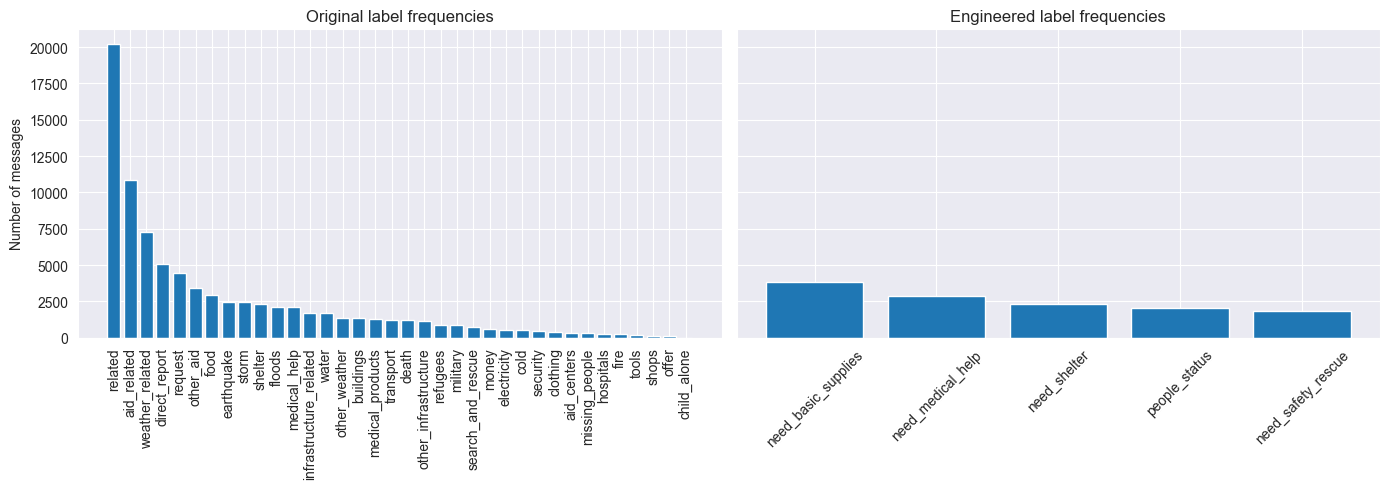

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
from utilities import helper

orig_labels = helper.get_label_columns(df_raw)
new_labels = helper.get_label_columns(df)
raw_counts = df_raw[orig_labels].sum().sort_values(ascending=False)
new_counts = df[new_labels].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].set_title("Original label frequencies")
axes[0].bar(raw_counts.index, raw_counts.values)
axes[0].set_ylabel("Number of messages")
axes[0].tick_params(axis="x", rotation=90)

axes[1].set_title("Engineered label frequencies")
axes[1].bar(new_counts.index, new_counts.values)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The bar chart on the left shows the original label frequency. As we can see, the more broad labels such as *related, aid_related* and *weather_related* dominate over the more specific ones. Labels such as *tools, shops* and *offer* are one of the rarest categories. The visualisation also confirms that the *child_alone* label does not apply to any of the messages.

The right bar chart presents the frequency of the new labels. Each label has a specific fraction of messages, none of which goes exceeds 5 thousand messages. Compared to the original categories, the new target is smaller, more balanced and focused specifically on project idea.

#### Labels per message
In this step, I will check the number of labels per message, before and after feature engineering to understand the density of the label annotations:

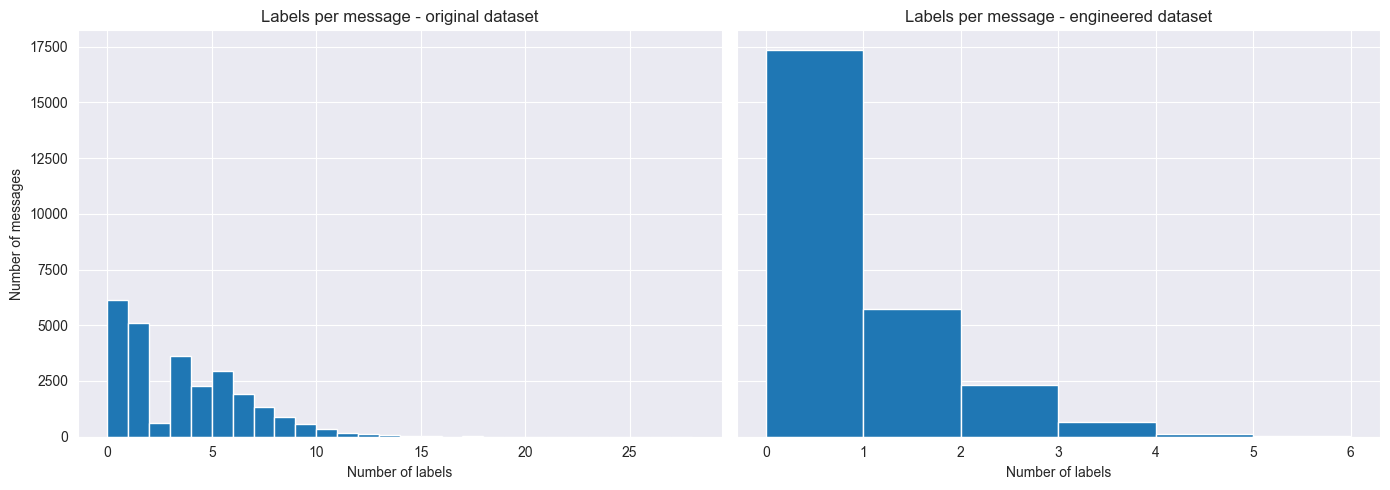

In [72]:
raw_label_counts = df_raw[orig_labels].sum(axis=1)
new_label_counts = df[new_labels].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(raw_label_counts, bins=range(0, raw_label_counts.max()+2))
axes[0].set_title("Labels per message - original dataset")
axes[0].set_xlabel("Number of labels")
axes[0].set_ylabel("Number of messages")

axes[1].hist(new_label_counts, bins=range(0, new_label_counts.max()+2))
axes[1].set_title("Labels per message - engineered dataset")
axes[1].set_xlabel("Number of labels")
plt.tight_layout()
plt.show()

The bar charts show the amount of labels each message has. Both charts are strongly right-skewed which indicates that most messages have a smaller amount of labels. The results in the original dataset chart show that the most messages have between 0 and 5 labels, while a smaller fraction receives even more. The right diagram shows that most messages do not express any needs or people status - a lot of messages do not have any labels. Among the remaining messages, most have between 1 and 2 labels. This reflects the fact that the new labels are more selective and need-focused, which leads to a clear imbalance between not-annotated messages and messages with at least 1 or more labels.

#### Check missingness
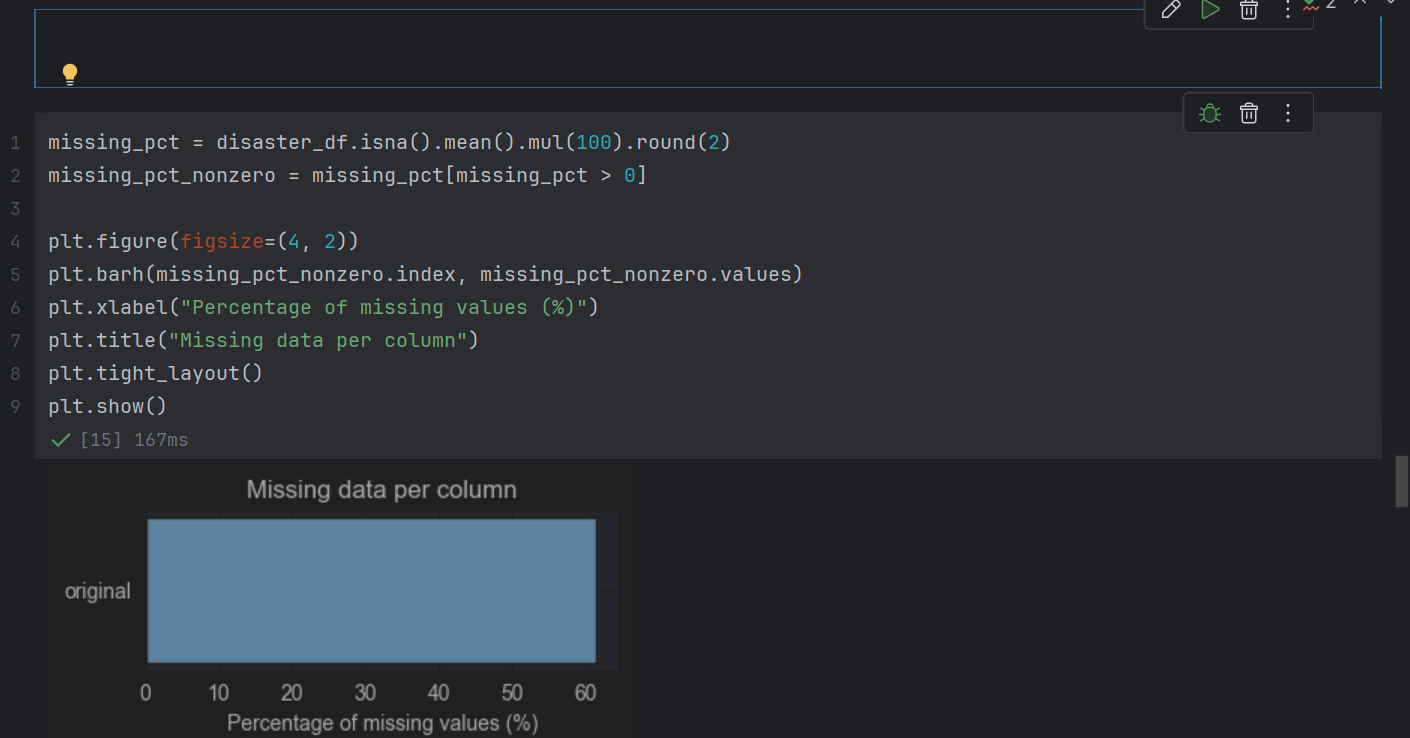

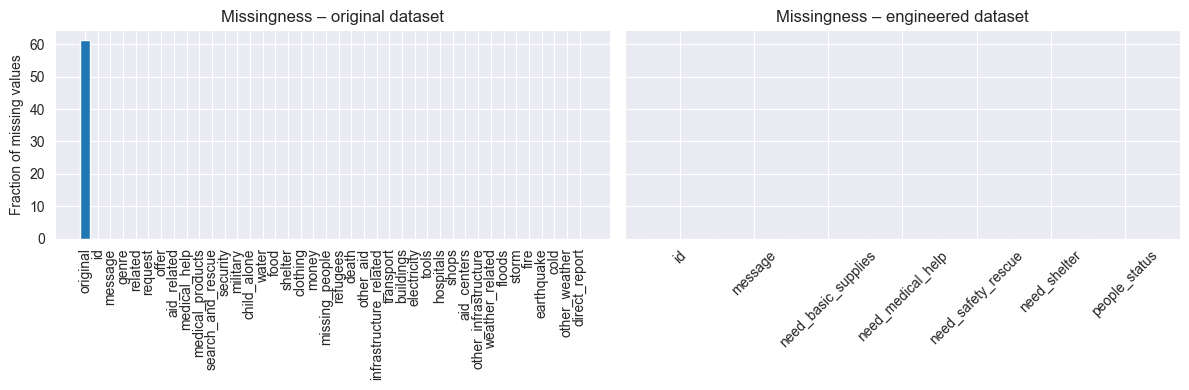

In [73]:
missing_raw = (df_raw.isna().mean()*100).sort_values(ascending=False)
missing_new = (df.isna().mean()*100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].bar(missing_raw.index, missing_raw.values)
axes[0].set_title("Missingness – original dataset")
axes[0].set_ylabel("Fraction of missing values")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(missing_new.index, missing_new.values)
axes[1].set_title("Missingness – engineered dataset")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The results above show that the only column, with detected missingness of more than 60%, is the *original* column the dataset before engineering, which was already expected. This column stores the original message before translating it to English, but if the message is originally written in English, the column stays empty. Since this project focuses only on the English version of the messages, this column was removed from the engineered dataset. The right graph confirms that after dropping the unnecessary columns no missingness remains in the data which will be used for modelling.

### Check samples quality
In this phase, I will perform manual quality check by going through the current dataset. The goal is to detect and remove noisy messages and verify that all samples are suitable for modeling. In the code below, I will sample 20 random messages to have a quick overview of the dataset:

In [74]:
pd.set_option("display.max_colwidth", None)
df[["id","message"]].sample(20)

,id,message
3247,3749,Wife's passport was in the USA at the time of the earthquake getting her visa renewed and it is still in the USA. (Requesting assistance)
9988,11365,RT CNN Find out how you can help make a difference to Haiti u2019s earthquake victims please visit Cnn.com Impact
25393,29361,Also that they are not electoral officials - there is a list of certain job categories that cannot run for election unless they resign their posts.
20336,23710,UNHCR has begun erecting temporary tents instead to house those who had spontaneously settled on the camp outskirts.
21283,24763,"Before the food crisis hit his region, he was known as a benefactor because he used to distribute one part of his crops to the poorest families that were greater in need in his village."
24982,28905,A large number of villagers alongwith their cattle have taken shelter on the expressway hence advisory for speed limit of 40 KM per hour has to be issued to avoid accidents by the State Government.
18351,21511,"Politicians from Touré down spoke out against `les amalgams', or half-truths that can be used by troublemakers to stir up hate campaigns, using the rebellion as a pretext for ethnic pogroms."
23535,27284,"Some 3,000 US marines and navy personnel have arrived on the coast of Kenya for a series of joint military exercises to be carried out in collaboration with Kenyan servicemen in the coastal region."
7883,8875,Whate they think to do about the school
20491,23889,"As the drought was expected to continue worsening, it was also essential to plan long-term strategies - including more sustainable methods of harvesting rainwater and plans to improve access to basic health services, she said, adding that Secretary-General Ban Ki-moon had called an interagency meeting, to be held on 12 July, to assess the United Nations response to the crisis in the Horn of Africa."


After looking through the whole dataset, I observed that some samples contain encoding-corrupted messages as well as annotation notes that start with "NOTES:" and express that the current messages are unclear or provide irrelevant for the project goal. Additionally, I will check for HTML artefacts and gibberish texts. Finally, I will analyse the message length and handle abnormal samples.

#### Get most common non-ASCII characters
Before detecting the encoding-corrupted samples, I will visualise the 20 most frequent non-ASCII characters observed in the dataset. These characters will be used to filter the corrupted messages:

['‚', 'à', 'ö', '¬', 'â', 'é', '√', '•', '¨', 'Ü', 'û', '£', 'ñ', '©', '∞', '°', 'á', '†', 'è', '±']


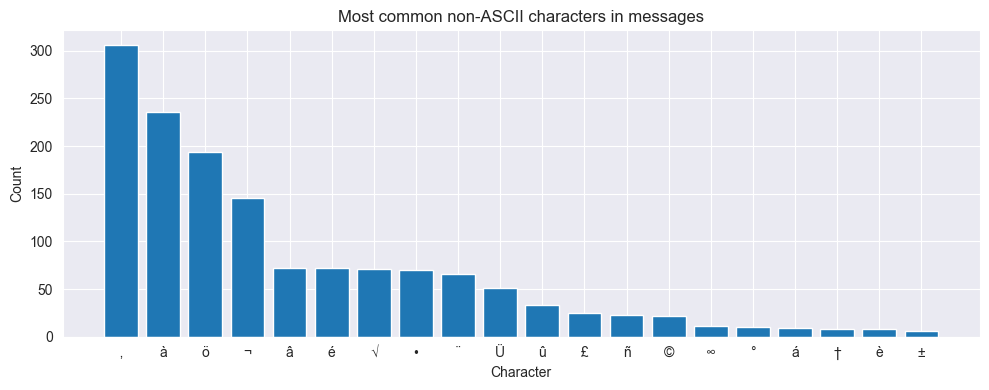

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

non_ascii_texts = df["message"][df["message"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)]
counts = Counter(ch for text in non_ascii_texts for ch in text if ord(ch) > 127)
top = counts.most_common(20)
chars = [c for c,_ in top]
freqs = [n for _,n in top]
print(chars)
plt.figure(figsize=(10,4))
plt.bar(range(len(chars)), freqs)
plt.xticks(range(len(chars)), chars)
plt.title("Most common non-ASCII characters in messages")
plt.xlabel("Character")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

From the barchart above, I can see that the most common non-ASCII characters are "‚¬√•¨©∞†±°£". The first character in the list looks like a comma, but it is a special quotation symbol that appears in encoding-corrupted texts. The symbols "‚¬√•¨©∞†±°£" do not carry any valuable linguistic meaning and will be used to detect corrupted messages. On the other hand, the symbols that look like normal English letters are valid accented letters that could be used in names, locations or multilingual texts and will be retained and handled separately.

#### Detect notes and corrupted messages

In [76]:
pd.set_option("display.max_colwidth", None)
mask_notes = df["message"].str.startswith("NOTES:", na=False)
enc_bad_pat = r"[‚¬√•¨©∞†±°£]"
mask_enc_corrupted = df["message"].str.contains(enc_bad_pat, na=False, regex=True)
notes_df = df.loc[mask_notes,["id","message"]]
enc_df = df.loc[mask_enc_corrupted,["id","message"]]

print("Detected notes:", int(mask_notes.sum()))
print("Detected encoding-corrupted:", int(mask_enc_corrupted.sum()))
notes_df.sample(10)

Detected notes: 329
Detected encoding-corrupted: 180


,id,message
8737,9807,"NOTES: THIS MESSAGE HAS NOT IMPORTANCE, THIS IS A PERSON THAT JORKING."
8118,9131,NOTES: this sms is not important because this person is playing.
3501,4030,NOTES: Is there a place that hire people?
8756,9835,NOTES: I don't understand this message.
7705,8687,NOTES: we don't understand this scripture
3362,3877,NOTES: Personal comment. Not an emergency.
4504,5146,NOTES: Asking what to do after the catastrophe
7907,8902,NOTES: It's a person that insult.It's not important.
9811,11099,NOTES: This message is not important to translate because he don't have any repport with my work.
9799,11081,"NOTES: The person express his feeling, the message is not important."


In [25]:
enc_df.sample(10)

,id,message
11679,13497,Post-earthquake video and commentary in Spanish of the Chequ‚àö¬©n Winery in Talca. http://youtu.be/dpQq4HsyU_E
23618,27377,"Observe strict hygienic practice namely; wash hands every time before eating and during food preparation, clean and disinfect every surfaces and utensils used for cooking, store cooked food separate from fresh food, cooking the food thoroughly and store cooked food in appropriate temperature, do not left cooked food in the room temperature more than 2 hours, keep cooked and perishable food in the refrigerator (<5° C), and reheat cooked food before eating (>60°C)."
11848,13698,escutando reden‚àö√ü‚àö¬£o -Fresno pela mil‚àö¬©‚àö¬©‚àö¬©‚àö¬©‚àö¬©sima vez..ser‚àö¬∞ q to virando emo???? n‚àö¬£oooo na mesma playlist tem e da‚àö‚â†- guilherme e santiago..h‚àö¬∞
12670,15105,I just wish I was at @AgaveNYC right now‚àö√± #sigh #sandy
11600,13400,The Pleasant Fishing Village of Constituci‚àö‚â•n was Rocked by the Earthquake and .. http://bit.ly/aDvgHS
12424,14785,"Canceled flight. Where's the hurricane party at?@HURRRlCANESANDY: TWERKIN UP ON THA EAST COAST‚àö√Ü @jaimeskyeeSandy is shutting down the subway. Daaamn, gurrrl."
11633,13437,RT VN24H: LUZ EN CONCEPCI‚àö√¨N: Gerente de CGE: Hay 30% de luz en #concepci‚àö‚â•n #talcahuano. En 72 horas debiera estar restablecido casi to ..
11745,13576,Hubble will pass over Santiago at mag 2.3 at 21:42 on 06/03. Moves from 20¬¨‚àû elevation NW to 38¬¨‚àû elevation N over 3 min
12513,14905,@SandysHurricane: I MOVE MAH BODY LIKE A CYCLONEEEEEEE.‚àö√Ü @AngMancuso Hahahahahalaurengel got some potatoes and a gourmet frozen pizza .. #hurricanepreparedne @Khim's Millennium Market http://t.co/u03mN2MP
12878,15386,Gas leak in the building. Working or trying to work from home #Sandy@MaudPas: Hello to a really crappy day #thatbitchsandy‚àö√Ü How's everything?Sandy has truly cut us down..I don't think @PaidInFull_Gill has brushed his dirty mouth since sandy hit tho.. #terry


In [77]:
df_clean = df.loc[~mask_notes].copy()
df_clean = df_clean.loc[~mask_enc_corrupted].copy()
df_clean.shape

(25671, 7)

In the code above, I detected 329 samples that start with "NOTES:" and 180 encoding-corrupted samples. After inspecting 10 random samples from each group, I decided to remove them as they do not provide any valuable information related to crisis help detection and would add noise during data preprocessing, which could mislead the models.

#### Inspect accented characters in messages
In this step, I will inspect 10 random samples from the accented character messages. To detect these samples, will use the most commonly used accented characters - à, ö, â, é, Ü, û, ñ, á, è. The goal of this step is to understand if these messages are still in their original language:

In [78]:
accent_pat = r"[àöâéÜûñáè]"
mask_accented = df_clean["message"].str.contains(accent_pat, na=False, regex=True)
accented_df = df_clean.loc[mask_accented,["id","message"]]
print("Detected accented character messages:", int(mask_accented.sum()))
accented_df.sample(10)

Detected accented character messages: 80


,id,message
18991,22221,"The effects of record high temperatures and the 'super El Niño' are already being felt: - Papua New Guinea has been hit by torrential rains that caused landslides, then drought and severe heat that withered crops, affecting 2 million people - Tonga, Samoa, Fiji and the Solomon Islands are experiencing reduced rainfall, affecting crops and water supplies."
16520,19465,"On January 25, 2013, Doctors Without Borders/Médecins Sans Frontières (MSF) sent a team to Gaza Province, one of the hardest-hit areas, to launch an emergency response in the city of Chokwe, 225 kilometers [about 140 miles] north of the capital city of Maputo."
18960,22185,"Since they are living within their own countries, IDPs remain under the legal jurisdiction of their national authorities, which may well be involved in the violence that they are fleeing, the medical charity, Médecins Sans Frontières, notes."
23827,27608,"The Burkinabé Red Cross has initiated a quick response in assisting 1,800 most vulnerable victims of the floods with mattresses, blankets, rice and millet out of its own emergency relief stocks."
25103,29040,"At the same time (between March and May) a series of mutinies in the army threatened to endanger the regime of President Blaise Compaoré, who has been in power since 1987."
15027,17817,NWS expects the current El Niño's effect to surpass the 1997/98 El Niño event that adversely impacting approximately 3 million people.
14803,17564,"Jusqu'à présent, les 133 femmes qui participent au projet à Mbar Toubab ont produit de la laitue, des tomates, des oignons, des pommes de terre, des gombos, des aubergines, des pastèques, des carottes, des choux et des navets."
13648,16295,"Prior to this disaster, we experienced devastating veld fires because we went almost immediately from winter to summer, with virtually no spring. Most of the displaced are living in temporary camps under tarpaulins, which are not appropriate for families, especially children, who will have to face chilly weather conditions very soon. At least 3,500 dead after 6.3-magnitude quake strikes Java's central region. The powerful cyclone smashed into the low-lying Irrawaddy delta, unleashing a storm surge as high as 12 feet, according to Reuters. On the night of 15 to 16 July, a hail storm with strong winds in Labé, middle Guinea, damaged homes and affected 869 households, and destroyed 322 hectares of crops, according to UN and government humanitarian officials just back from an evaluation of the area. Ministry officials said they had been trying to deploy health workers to badly affected areas using two military helicopters, but the aircraft were only of limited use due to the continuing appalling weather conditions, a spokesman said. SHANGHAI, June 15, 2009 (AFP) - At least 14 people were killed and more than 180 others were injured in a severe hail storm that destroyed thousands of homes across eastern China's Anhui province, authorities said Monday. By August 29, kharif crops were sown in 966.25 lakh hectares. Floods triggered by monsoon rains are affecting some 5.4 million people and displaced 1.8 million, according to the agency. SATKORLAK PB East Nusa Tenggara reported that flash floods occurred in Reok Sub-district and landslides hit seven sub-districts, namely Cibal, Wae Ri'I, Lamba Leda, Poco Ranaka, Ruteng, Langke Rembong, and Kota Komba. But the roads that remain along the coast are now in deeper water, the mud remains, the potential for disease increases, and the cold dampness causes people on the margins to be even more vulnerable. A massive earthquake measuring 7.8 on the Richter scale shook Nepal on late Saturday killing and injuring many people. To meet these needs, NRC organised two trainings for 78 male and female primary school teachers in Bajaur and Mohmand Agencies with the objective to enhance the capacity in current teaching-learning approaches, including lesson planning, class room management, dropout prevention, community mobilizat

The results above show that there are 80 accented character samples detected in the dataset. As we can see from the examples above, most of those characters appear in nouns such as names and locations, but the main structure of the sentence remains in English. Therefore, I will not remove them from the dataset as they are considered valid text messages.

#### Detect HTML artefacts
HTML artefacts are leftovers from web scraping where some characters are stored in an escaped form ("&amp;", "&lt;", "&quot;") instead of being stored in their normal form (&, <, "). I decided to detect whether such artefacts appear in the dataset, because in the dataset documentation was stated that some messages were scraped from different platforms. These artefacts could introduce noise during preprocessing, which is why it is important to detect and decide how to handle them properly:

In [79]:
html_pat = r"&(?:amp|lt|gt|quot|apos|nbsp);|&#\d+;"
mask_html = df_clean["message"].str.contains(html_pat, na=False, regex=True)
html_df = df_clean.loc[mask_html,["id","message"]]
print("Detected HTML artefacts:", int(mask_html.sum()))
html_df

Detected HTML artefacts: 58


,id,message
11498,13267,"RT ilvia_callado: 12 minutes to showtime..CETV? Por radio listin 99.7fm. -&gt; Deberian de pasarlo en Santiago, me gusta but i can't listen"
11500,13271,RT watche: RT @rogerclowater Pictures from the Santiago Airport after Chile earthquake http://bit.ly/aJof50 &lt;- Really impressing!
11713,13537,"/ #offtopic: verbiage refresh! Welcome to Whatever Whenever at the W in Santiago, this is Diego, What is your wish?. Suena tan lindooo &lt;3 &lt;3"
11722,13548,"Chile ---&gt; There was a 8.8 magnitude earthquake (Feb. 27) with an epicenter 70 miles from Concepcion, the country's second largest city."
11913,13784,Boa noite.. Dake a poko to pegando a estrada.. vo p santiago conhecer E! &lt;3 *---*
12007,13899,RT ickybuck: My friend @franginnini lives in Santiago Chile im happy to here her family and friends are fine.Yes &lt;&lt; THANK YOU! How are you
12340,14687,"hurricane sandy COULD be repeat of Irene (aka best weekend ever!) with @margotmiller &amp; @Tristanpz!!Hurrizard, or a Blizicane. Either way I don't like this storm coming our way! #mothernatureisbeingabitch"
12367,14719,"When you're suddenly running, tipsy, w wind in your hair past a Brooklyn construction site &amp; hurricane's coming but you're flying away soon.Does anyone wanna take me in for the hurricane so I don't have to evacuate? Hahah"
12374,14726,"Buying stuff for sandy! (@CVS) http://t.co/9lms7WcuRacked up on frosted flakes &amp; drakes cookies before that bitch ""Sandy"" comeA friend's emergency kit list from her apartment suggests including ""Photos of family members."" #SandyPanic http://t.co/uNZBANTy"
12388,14742,#cupcake before the big #Storm _#rubeyg @5th &amp; 72nd http://t.co/ZwKMjkkz


The results show that there are 58 samples with HTML artefacts detected in the dataset. After reading all of them, I decided that some are not worthy keeping as they are mostly noisy messages of people jocking about the hurricane Sandy rather than requests for help or crisis-related reports. In the code below, I manually selected 13 samples to retain and removed rest:

In [80]:
keep = [13548, 14953, 14956, 15169, 15240, 15258, 15379, 15422, 15592, 15612, 15630, 15693, 15710]
kept_df = html_df.loc[html_df["id"].isin(keep)].copy()
kept_df

,id,message
11722,13548,"Chile ---&gt; There was a 8.8 magnitude earthquake (Feb. 27) with an epicenter 70 miles from Concepcion, the country's second largest city."
12554,14953,"Wind 16.0 mph NNE. Barometer 982.36 mb, gust 31.0, Temp 56.9 &amp;deg;F. Rain 0.00 in. Humidity 95% hurricane cam http://t.co/Sq2ekENu"
12556,14956,"Wind 16.0 mph NNE. Barometer 982.09 mb, gust 31.0, Temp 56.9 &amp;deg;F. Rain 0.00 in. Humidity 95% hurricane cam http://t.co/Sq2ekENuWind 16.0 mph NNE. Barometer 981.68 mb, gust 26.0, Temp 57.1 &amp;deg;F. Rain 0.00 in. Humidity 95% hurricane cam http://t.co/Sq2ekENu"
12711,15169,"All #NYC bridges, tunnels &amp; mta closed; over 2.8 million without power #Sandy causing So much havoc!!! Praying 4 us all"
12768,15240,"I have officially made it through my first storm in the newsroom. I can finally go home and see what damage Sandy has left Manchester withSo grateful to see another day. I am thankful for the NYPD, FDNY, emergency workers, health pros, &amp; city employees working through #Sandy.New York last night #nofilter #newyork #nyc #hurricane #sandy @NYU Weinstein Residence Hall http://t.co/K23TS8wC"
12782,15258,oshingnyc hope there's a way electrical companies work out a plan to restore power quickly to the elderly &amp; people who live alone #sandy
12872,15379,"here in Northern Jersey, half hour west of NYC, AT&amp;T cell service has been non-existent to spotty, Verizon close to normal #HURRICANESANDYSandy traffic..2 hours from #Astoria to #Manhattan. Walking is faster. #sandy #@Ed Koch Queensboro Bridge http://t.co/orVVbQ1YSandyn12nj they should give all the kids the week off and don't even make up the days, they are learning more about life from the storm"
12908,15422,"Just saw a fleet of Missouri Urban Search &amp; Rescue vehicles in Brooklyn going into Manhattan.Thanks for the support Missouri! #Sandy#Sandy clean-up crew juxtaposed aside #Halloween revelers in Cobble Hill, Brooklyn. http://t.co/Wo7bVEi3"
13034,15592,NYC. #Sandy relief efforts. Donation dropoff points all over. Here's one I walked by. I found inf @New York http://t.co/MENeNp2sSo Hurricane Sandy has gone but a snowstorm is on the way for Wednesday apparently. Oh joy!Ordered #restoretheshore shirt &amp; truckers hat from @ERGOclothing. 100% of the proceeds go to Hurricane Sandy relief. Get yours! #sandyhelp
13045,15612,ityofHoboken any idea where there is a working B of A ATM? &amp; what locations r handing out food? I have no cash &amp; no food! #sandyproblems


In [81]:
drop_ids = df_clean.loc[mask_html & ~df_clean["id"].isin(keep), "id"]
df_clean = df_clean.loc[~df_clean["id"].isin(drop_ids)].copy()
df_clean.shape

(25626, 7)

Finally, I removed the 45 noisy samples. In the data preprocessing step, I will normalize the HTML artefacts of the 13 remaining messages to avoid introducing artificial tokens and keep the TF-IDF vocabulary small and consistent.

#### Detect gibberish
In this step, I detect gibberish messages, which consist of punctuation and/or symbols and do not contain any letters or digits. The results below show that there are 4 detected gibberish messages. Those samples are removed as they are not realistic inputs and would only add noise in the vocabulary.

In [82]:
pd.set_option("display.max_colwidth", None)
mask_gibberish = df_clean["message"].str.contains(r"^[^A-Za-z0-9]+$", na=False, regex=True)
gibberish_df = df_clean.loc[mask_gibberish,["id","message"]]
print("Detected gibberish:", int(mask_gibberish.sum()))
gibberish_df

Detected gibberish: 4


,id,message
7534,8497,//// // @:@
12185,14315,
12189,14329,.
12222,14428,


In [83]:
df_clean = df_clean.loc[~mask_gibberish].copy()
df_clean.shape

(25622, 7)

Next, I will calculate the digit ratio to detect digit-dominated messages. Those samples are often noisy and consist of combinations of letters and numbers, which have no informative value. I will use the statistics below to select a threshold for digit-heavy outliers:

In [84]:
import pandas as pd

msg = df_clean["message"].fillna("").astype(str).str.strip()
char_len = msg.str.len().clip(lower=1)

digit_cnt = msg.str.count(r"\d")
digit_ratio = digit_cnt / char_len
summary = digit_ratio.describe(percentiles=[.90, .95, .97, .98, .99])
print(summary)

count    25622.000000
mean         0.008859
std          0.020308
min          0.000000
50%          0.000000
90%          0.030769
95%          0.047619
97%          0.060241
98%          0.071429
99%          0.090909
max          0.523256
Name: message, dtype: float64


The results above show that half of the samples in the dataset do not contain any digits. Overall, the mean value (0.008859) indicates that there is a low digit appearance across all samples, but the distribution is right-skewed - there is a small tail of digit-heavy messages. The max digit ratio is 0.523, which shows that over half of the characters in those samples are digits. To detect those samples, I will take the digit ratio of the 99th percentile as a threshold.
##### Inspect digit-heavy messages
In this step, I filter the digit-heavy samples, show the number of detected outliers (266) and divide them into 3 batches for manual inspection. Later, I store only the ids of samples that will be excluded from the dataset in a list called *drop_ids*:

In [85]:
pd.set_option("display.max_rows", None)
mask_digit_heavy = digit_ratio >= 0.09
print("Digit-heavy count:", int(mask_digit_heavy.sum()))
gibberish_df = df_clean.loc[mask_digit_heavy, ["id", "message"]]
batch1 = gibberish_df.iloc[0:100]
batch1

Digit-heavy count: 266


,id,message
269,324,rin more or less 3000 people - incomplete
723,879,4636 : MInustah fm radio is working now on 106. 1 FM and 94. 9FM
954,1150,4636 i heard about it on minustah fm 106. 1 fm and 94. 9 fm. i know thank you
976,1179,We can send it to 4636 I don't have money
1173,1404,Haiti : informations on a possible new quake. Date 22 Jan 2010.
1175,1406,How about the earthquake for Friday 22 January 2010? Thanks
1330,1574,4636 we have nothing to live on in Bel-Air
1336,1581,I need information on the number 4636
2179,2507,"Almost everyone in Carrefour is hungry. People in Repo 32 and 50, Lamantin 52 and 54."
2429,2797,"details on earthquake damage from january 12th, 2010, Gressier Haiti. 1800 houses destroyed, 3900 houses damaged, 1827 dead, 236 baby, more than 2000 . .. A last word seem to be wounded. .. . but message was cut."


In [86]:
drop_ids = [5836, 6327, 6328, 6329, 6430, 8063, 8099, 8192, 8358, 8646, 8698, 8699, 9105, 9155, 9156, 9239, 9595, 9698, 9777, 9874, 9917, 9949, 9967, 9976, 9977, 10960, 10961, 11082, 11200]
batch2 = gibberish_df.iloc[100:200]
batch2

,id,message
9972,11341,Haiti hit by largest earthquake in over 200 years http j.mp 6X12Kj
9982,11354,RT paipibat RT Teelek Flickr paipibat u0e15 u0e34 u0e14 u0e15 u0e32 u0e21 u0e20 u0e32 u0e1e u0e08 u0e32 u0e01 u0e40 u0e1e u0e34 u0e48 u0e21 u0e40 u0e15 u0e34 u0e21 u0e08 u0e32 u0e01 Flickr u0e44 u0e14 u0e49 u0e17 u0e35 u0e48 u0e19 u0e35 u0e48 u0e04 u0e23 u0e31 u0e1a http bit.ly 60OxGS #Haiti #Earthquake
10042,11449,https secure.unicefusa.org site Donation2?df_id=6680&6680.donation=form1 Donate for Haiti earthquake relief
10106,11550,Earthquake Hits Haiti first film of horror 13 Jan 2010 http bit.ly 5A5TIU
10157,11620,Haiti Earthquake 12 January 2010 | 12 Jan Haiti Earthquake News .. Haiti Earthquake 12 January 2010 | 12 Jan . http bit.ly 547kZb
10174,11641,u30cf u30a4 u30c1 u306e u5730 u9707 u3001 u5915 u520a u306b u306f u6b7b u8005 u591a u6570 u3068 u3057 u304b u66f8 u3044 u3066 u306a u3044 u3051 u3069 u3001 u4e0b u624b u3059 u308b u3068 u6570 u5343 u4eba u898f u6a21 u3060 u3063 u3066 uff01 #haiti #earthquake
10182,11654,I rated a YouTube video 5 out of 5 stars HAITI EARTHQUAKE VIDEO 12 JANUARY 2010 http youtu.be mOS 3wJDEK4?a
10367,11904,RT YELEHAITI The magnitude 7.0 earthquake u2013 and several very strong aftershocks u2013 struck only 10 miles from Port au Prince..
10375,11915,Earthquake List for 10 degree Map Centered at 20 u00b0N 75 u00b0W http bit.ly 4LEdrj M7.0 u4e3b u9707 u540e uff0c u8ba131 u6b21 u4f59 u9707 M4.7 M5.7 &gt 10.0 KM Depth #HAITI Region
10413,11965,Haitan Earthquake As I type this it is 8 18 am Wednesday 13th January. I u2019m watching BBC morning news and they u2019r.. http su.pr 17YpvE


In [87]:
drop_ids.extend([11354, 11641, 11915, 12069, 14909])
batch3 = gibberish_df.iloc[200:266]
batch3

,id,message
21047,24505,"By mid-June, the ministry will also have in store 100,000 vaccines for the prevention of cholera, 20,000 for hydrophobia and30,000 for measles, he added."
21192,24662,"In addition 73,000 blankets, 10,000 pieces of woollen clothes, 40 metric tonnes of medicines, 30 metric tonnes of sugar, drinking water 27,200 litres of water, 917 tarpaulines and 4000 litres of fresh milk have been mobilized."
21234,24707,"PRCS has dispatched relief goods including 5,148 tents, 22,174 blankets, 6,860 plastic sheets, 560 coal stoves, 1,945 kitchen Set, 4,500 jerry can, 1,496 Quilts and 2,250 hygiene kit to Ziarat and Pishin."
21422,24909,15 lacs and dry food (100kg flatten rice and 100kg biscuits)
21523,25020,"* 15,040 blankets * 8,340 tarps * 550 rolls of plastic sheeting * 8,000 kitchen sets * 8,000 five-gallon buckets with lids"
21579,25084,"In Zambia: Charles Mushitu, Secretary General, Zambia Red Cross Society, Lusaka; Email: zrcs@zamnet.zm; Phone +260.1.25.36.61; Fax +260.1.25.22.19"
21652,25172,"Some 170,000 Malians left northern Mali for neighbouring countries and 260,000 have fled their homes to seek refuge elsewhere within Mali since early 2012, according to the UN."
21653,25175,"Soil is saline and underground water has 3,000-4,000 dissolved salts/ppm."
21654,25176,"UNFPA is providing 25,000 personal hygiene packs for a total amount of USD 160,000."
21729,25256,4100 passengers evacuated between 27th to 29th December.


In [88]:
df_clean = df_clean[~df_clean["id"].isin(drop_ids)].copy()
df_clean.shape

(25588, 7)

After inspecting all three batches of 266 samples, I removed 34 messages which clearly consisted of unreadable non-informative texts. Digit-heavy messages that provided a clear report related to different crisis were retained, even if they were not connected to the specific 5 target variables.

#### Detect metadata
From the observations above, I saw message examples with hashtags(#), user-mentions(@) and URLs. In this step, I will visualise the distributions of the 3 metadata elements to understand how many samples contain each of them and their overall occurrence in the dataset:

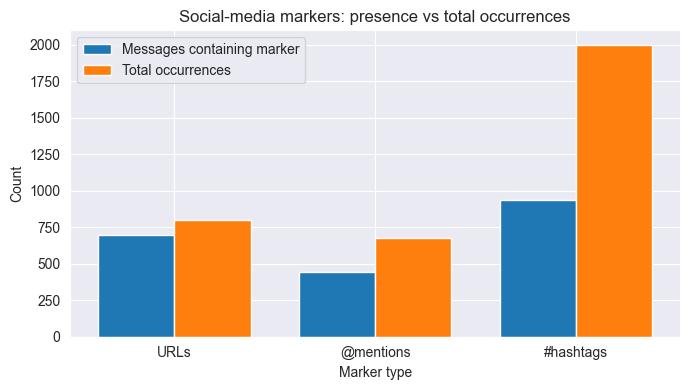

In [89]:
import numpy as np
import matplotlib.pyplot as plt

has_url = df_clean["message"].str.contains(r"(?:https?://\S+|www\.\S+|t\.co/\S+|bit\.ly/\S+)", na=False, regex=True)
has_mention = df_clean["message"].str.contains(r"@\w+", na=False, regex=True)
has_hashtag = df_clean["message"].str.contains(r"#\w+", na=False, regex=True)
url_cnt = df_clean["message"].str.count(r"(?:https?://\S+|www\.\S+|t\.co/\S+|bit\.ly/\S+)")
mention_cnt = df_clean["message"].str.count(r"@\w+")
hashtag_cnt = df_clean["message"].str.count(r"#\w+")
marker_labels = ["URLs", "@mentions", "#hashtags"]
msg_with = np.array([has_url.sum(), has_mention.sum(), has_hashtag.sum()], dtype=int)
total_occ = np.array([url_cnt.sum(), mention_cnt.sum(), hashtag_cnt.sum()], dtype=int)

x = np.arange(len(marker_labels))
plt.figure(figsize=(7,4))
plt.bar(x - 0.38/2, msg_with, width=0.38, label="Messages containing marker")
plt.bar(x + 0.38/2, total_occ, width=0.38, label="Total occurrences")
plt.title("Social-media markers: presence vs total occurrences")
plt.xlabel("Marker type")
plt.ylabel("Count")
plt.xticks(x, marker_labels)
plt.legend()
plt.tight_layout()
plt.show()

The visualisation above shows that URLs appear in slightly less than 750 messages, @mentions appear in almost 500 messages and #hashtags appear in almost 1000 samples. However, the occurrence is higher than the detected presence, which indicates some messages include multiple URLs, @mentions and/or #hashtags. This suggests that a set of messages contain social-media style. Messages that contain a lot of markers, usually do not contain important crisis information, which is why I will filter and inspect outliers that could introduce noise.

#### Metadata marker density analysis
In this step, I compute the total metadata-marker count(meta_total) and density(meta_ratio) to help me analyse how social-media-heavy messages are and flag outliers for manual inspection:

In [90]:
meta_total = (df_clean["message"].str.count(r"(?:https?://\S+|www\.\S+|t\.co/\S+|bit\.ly/\S+)")+df_clean["message"].str.count(r"@\w+")+df_clean["message"].str.count(r"#\w+"))
tok_cnt = df_clean["message"].str.split().str.len().clip(lower=1)
meta_ratio = meta_total / tok_cnt
summary = pd.DataFrame({"meta_total": meta_total,"meta_ratio": meta_ratio}).describe(percentiles=[0.01, 0.05, 0.95, 0.99])
print(summary)

         meta_total    meta_ratio
count  25588.000000  25588.000000
mean       0.135650      0.007490
std        0.837856      0.045143
min        0.000000      0.000000
1%         0.000000      0.000000
5%         0.000000      0.000000
50%        0.000000      0.000000
95%        1.000000      0.030303
99%        4.000000      0.200000
max       47.000000      1.146341


Overall, the results show that messages with markers are uncommon and more than half of the dataset contains none. However, there is a tail of marker-heavy messages starting from the 99th percentile, which motivates flagging messages with ≥ 4 marker count or ≥ 0.20 marker ratio.
#### Detect metadata-heavy messages
In the code below, I detected that there are 396 metadata-heavy messages. For easier inspection, I divided them into 4 batches and created a "keep" list where I store the ids of the messages that I decided not to remove:

In [91]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)
outlier_mask = (meta_total >= 4) | (meta_ratio >= 0.20)
df_meta_outliers = df_clean.loc[outlier_mask, ["id","message"]].copy()
print("Detected outliers:", int(outlier_mask.sum()))
batch1 = df_meta_outliers.iloc[0:100]
batch1

Detected outliers: 396


,id,message
6776,7700,paklascencion##s
7328,8283,http://wap.sina.comhttp://wap.sina.com
8265,9287,I@UU#UTGa UTUUUXU UU@UU@UUp U.
8835,9947,Nokia.com http://ea.mobile.nokia.com/ea/graphics
9781,11053,"@W@E@N@ @S@E@ @ @Y@O@N@ @ @V@I@K@T@I@M@ @ @K@A@T@A@S@T@R@O@F@ @1@2@ @J@A@N@V@Y@E@ @ @M@'@ @A@P@ @M@A@N@D@E@ @N@O@U@ @ @N@E@N@P@@T@ Mimi you start to finish with me, I love you to have a normal home with you, without hassle, without getting angry, I wil"
9916,11254,#Pray4Those who have been affected by the earthquake in #HAITI
10026,11427,#pleaseexplainwhy FOX isn t reporting the earthquake in Haiti??? #FOXfail
10056,11475,Yele Earthquake Goodnight #dontfollowmeif #TeamConan #omgfacts #LilTwistLoveAffair #Pleaseexplainwhy Help Haiti #nowplaying
10113,11559,real time photos of streaming from #haiti http tinyurl.com ybboxnw #earthquake #helphaiti
10139,11593,Legitimate #Haiti #earthquake sites SFChronicle Updated #donation list & info http bit.ly 7B01X9


In [92]:
keep = [11779, 11814, 12273, 12549, 12639, 12714, 12863, 13029, 13129, 13329, 13330, 14661, 14662]
batch2 = df_meta_outliers.iloc[100:199]
batch2

,id,message
12393,14747,"This is why I love hurricanes Riding all night!! #firefighterproblems @Farmingville Fire Department http://t.co/sJdQmlGdGettin ready for this stormDear #Sandy, you may have been badass in Grease but I would appreciate if you didn't get all in my business this week."
12394,14749,Hurricane Sandy. @Bedford Avenue http://t.co/HFMNVpFrIf Frankenstorm sweeps me away I made sure to have my fav meal with my fav person - @mike_jorda (@The Hamilton Inn) http://t.co/6fuRvjCoPhone calls from people who wants to know my game plan. #HurricaneSandy #TrueFriendsWell if I die cause this Daum hurricane just wanted to say everyone have a nice swim lmao
12398,14753,#gracejones #hurricane tour #frankenstorm #newyorkcity @Roseland Ballroom http://t.co/crdV3EAq@brooklyn_news will alternate side parking be suspended for the hurricane?Appropriate supplies for the Hurricane #Sandy http://t.co/kwgWMT8R
12399,14755,Lovely quiches pre-Sandy #waiting #sandy #frankenstorm @The Blue Stove http://t.co/63HxOOLh
12401,14757,"arisolNY gracias bon bon.cuidate tu tambien #sandy on the way.READY http://t.co/o21LxwUOVery small amount of people heading back IN to the city today.. #Sandy (@New Haven Union Station w/ 3 others) http://t.co/xgYiaooDAlready the dumb, stupid, ignor"
12402,14758,"Everyone is spazzing about the hurricane and I'm spazzing cause my eyebrows aren't done. The fuck?Does anyone know of any good drink specials in the West Village? #sandy #ZoneA @Casa Tilbury http://t.co/Kbi5Euniso Ima be in my crib all alone when that hurricane hit -.- Ima need some damn company!!!#theworldsending @Frankenstorm Apocalypse- Hurricane Sandy http://t.co/yNQkFREVLove seeing what people stock up on in prep for #SandyHomes of millions could face flooding, National Hurricane Center says http://t.co/DcJ8fkAMAll these hurricane sandy statuses are extremely annoying"
12404,14761,Dont forget your #frankenstormsupplies @Whole Foods http://t.co/nFKFR3OhWalking to taco bell cuz we ain't scared of no Damn hurricane http://t.co/aNT57AytHow I prepare for Sandy: I get a pedicure.
12406,14766,The clam before the storm.The hurricane shop! #hurricanesandy @New York City http://t.co/DQn1Yhjv
12412,14772,Getting emergency provisions for Sandy. (@Growler Station) http://t.co/kJxJ4T4bHurricane sandy lmfaoooo http://t.co/bPUcatjF
12413,14773,"It's not even hurricane season y'allSitting in @CarrollPark with my mocha latte from @smithcanteen .. Enjoying the calm before the storm #SandyEveryone please stay inside and be safe during this hurricane! I am praying for all of us in ct, ny, and nj! Keep your pets safe too! #sandy"


In [93]:
keep.extend([14740, 14863,14925, 14940, 14959, 15018, 15037, 15068, 15082])
batch3 = df_meta_outliers.iloc[199:299]
batch3

,id,message
12714,15172,"Sandy you're a heartless bitch #sandy #HurricaneSandy@candrews669 I can tolerate having no power in the kitchen and living room, but damn is it ever hard to take a shit in the dark #sandy"
12717,15176,haig that sucks dude. At least the @49ers are dominating. #SandySo glad we have #twitter and #FaceBook to keep #InContact with #FriendsAndFamily right now! #BeSafe #HurricaneSandy
12719,15178,Power up fifth avenue #sandy @Andaz 5th Avenue http://t.co/Jepyb7LF
12721,15183,am_Dilly if the parkways weren't closed. I should have evacuated to marywood! #kickingmyself #ohwait #sandysdoingitformeBut like where's Jarred #sandygivehimback #illsmackahoe #myboynotyours
12722,15184,this hurricane is boring (@Cain's Tavern) http://t.co/wAXD4xOS
12727,15189,Falling asleep to @craigowens to make this hurricane go by #jerseyshoreproblems #besafe #hurricane #Sandy
12728,15190,#Sandy #Brooklyn #Battery #Tunnel @Brooklyn-Battery Tunnel (Hugh L. Carey Tunnel) http://t.co/b75zXje8
12732,15194,"We good! #OutChea #Brooklyn #EFlatbush #NYC #HurricaneSandy @Brooklyn, NY http://t.co/DaEazEFY"
12735,15198,"Finally getting cell service. Still without power. #sandy #hurricane #frankenstormWhen there's a hurricane the calories don't countI haven't heard from sandy .Sandy, you are seriously a B #Sandy #abcliving"
12736,15199,Floods over by our house. #harlem #sandybaby http://t.co/mURfNwRY


In [94]:
keep.extend([15199, 15207, 15239, 15240, 15338, 15349, 15367, 15371, 15379, 15381, 15382, 15419, 15421, 15422, 15457])
batch4 = df_meta_outliers.iloc[299:400]
batch4

,id,message
12946,15473,andyyCheeks_ aweee pobresita ima pray _ for ur lights#frankenstorm #frenchbulldog I love syd_shap_khos to death happy jappy helloween !!!!!!!! @NyQuil http://t.co/wSKBVfSo@shaybabiiii it wasn't bad considering working during that shit lol and yea My bd
12947,15475,Pumpkin better then Cake..finished product is delicious!!! #jcthinks #frankenstorm #fatk @Home Sweet Home http://t.co/IaJHL2v3
12948,15476,Thankfully only my fence is the major problem. #hurricanesandy @Nick's Badass Castle http://t.co/BbpzWAbU
12949,15477,OT97 listening to the #basementmix in my car while charging my phone thanks to Sandy screwing up my power. #ILoveHipHop#sandycantstopme Don't let her stop you. #floodproof #keepgoing
12951,15481,"First, Kudos to the New York MTA staff for getting the subway mostly running not much over 48 hours after Sandy. And it's free today! :)Driving to PA just for gas #EastCoastBlackout #FrankenstormRT @mashable: What It Takes to Get the Internet Running After #Sandy http://t.co/zfY9lEjcHappy to be taking shelter from the storm at the NoMad Hotel. No power, no water at home. http://t.co/IFvMqvL4"
12953,15483,I feel bad for anyone named sandy they will never live this down #namechange #sandy jokes are away to easy#army #nationalguard #hurricane #hurricanesandy #nyc #newyorkcity #boom @New York City http://t.co/LcfbAmNq
12954,15485,"To rephrase what I had stated, #hurricanesandy was a #bitchstorm WHEN it CAME to Connecticut! Ye @Taco Bell http://t.co/wQqu19rm"
12957,15488,"#Hoboken Volunteer Ambulance under water during #hurricanesandy. They will need a fundraiser! @Hoboken, NJ http://t.co/NhrbtFKK"
12964,15497,"1. Whole Foods is OPEN 2. NO LINES 3. REAL FOOODD!! #sandy @Whole Foods http://t.co/SnQgYLZwClifton schools still without power, closed on Thursday -NorthJersey.com http://t.co/4OcLhyie #Clifton #NJ"
12965,15498,I'm afraid I'm getting used to be in the darkness. #outageny #nyc #manhattan #hurricanesa @36 East 36th St http://t.co/rBR0zuQj


In [95]:
keep.extend([15471, 15472, 15481, 15488, 15517, 15539, 15563, 15564, 15569, 15572, 15592, 15607, 15616, 15619, 15630, 15656, 15670, 15671, 15693, 15723, 15727])
keep_ids = set(keep)
df_outliers_remove = df_meta_outliers[~df_meta_outliers["id"].isin(keep_ids)].copy()
remove_ids = df_outliers_remove["id"].tolist()
df_clean = df_clean[~df_clean["id"].isin(remove_ids)]
df_clean.shape

(25250, 7)

After manually inspecting all 4 batches, I observed a lot of social-media-style comments from people expressing different kind of emotions - mainly jocking rather than actionable crisis needs, about the Hurricane Sandy. I selected a small subset of samples, which contained requests for donations and different needs, some of which not included in the project scope, but still considered important. Additionally, samples with people offering to volunteer or provide help were also retained. After removing the detected outlier samples, the dataset consists of 25280 rows.

#### Duplicate and near duplicate detection
Crisis messages usually contain repetitive or similar messages asking for help or information, which could cause data leakage or bias the models. In the first step of this phase, I will detect the exact similar messages. To ensure messages are compared consistently, I remove any whitespace that could appear before or after the text:

In [98]:
msg = df_clean["message"].str.strip()
dup_mask = msg.duplicated(keep=False)

print("Exact duplicate rows:", int(dup_mask.sum()))
df_clean.loc[dup_mask, ["id","message"]].head()

Exact duplicate rows: 10


,id,message
1342,1587,I would like to have some information
1982,2287,I need information on the earthquake.
2234,2579,We need help at delmas 75 across from kiskeya christian school. Tank u!
3076,3555,I need information on the earthquake.
3223,3724,We need help at delmas 75 across from kiskeya christian school. Tank u!


In [99]:
keep_one_mask = ~msg.duplicated(keep="first")
df_clean =  df_clean.loc[keep_one_mask].copy()
df_clean.shape

(25245, 7)

The results above show that there are 10 detected exact duplicate samples. I sampled the first five samples in the dataset to confirm the detected messages are actually exact duplicates. To handle this problem properly, I decided to keep only the first message of the detected duplicates. To confirm that only half of the detected amount was dropped, I checked the shape of the dataset - 5 rows were dropped confirming the proper deduplication.

Next, I detect near-duplicate messages that could appear  for example, due to someone spamming organisations for help. To properly detect those samples, I lowercase the texts and replace any URLs, emails or numbers with fixed tokens. Lastly, I clean up whitespaces:

In [100]:
msg_norm = (df_clean["message"].str.lower().str.replace(r"(https?://\S+|www\.\S+)", " URL ", regex=True).str.replace(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAIL ", regex=True).str.replace(r"\d+", " NUM ", regex=True).str.replace(r"\s+", " ", regex=True).str.strip())
near_dup_mask = msg_norm.duplicated(keep=False)

print("Near-duplicate rows:", int(near_dup_mask.sum()))
df_clean.loc[near_dup_mask, ["id","message"]].assign(norm=msg_norm[near_dup_mask]).head()

Near-duplicate rows: 30


,id,message,norm
1388,1636,I would like to know when the aftershocks will end,i would like to know when the aftershocks will end
1736,2009,i would like to know when the aftershocks will end,i would like to know when the aftershocks will end
2949,3408,information on the earthquake.,information on the earthquake.
3165,3655,Information on the earthquake.,information on the earthquake.
6728,7650,information about the earthquake.,information about the earthquake.


In [101]:
first_in_group_mask = ~msg_norm.duplicated(keep="first")
keep_mask = (~near_dup_mask) | first_in_group_mask
df_clean = df_clean.loc[keep_mask].copy()
df_clean.shape

(25228, 7)

There are 30 near-duplicated detected messages. To confirm the detected samples are duplicate and differ only in specific parts, I print the raw message as well as the normalized one. After inspecting the detected messages, I decided to deduplicate the dataset by keeping the first detected sample and dropping the rest. The shape results confirm the deduplication was performed correctly.

#### Check message length
In this step, I will inspect message length based on the amount of words detected in each text. The plots below will help me identify extremely short or long messages and guide my decision on whether I should remove those outliers:

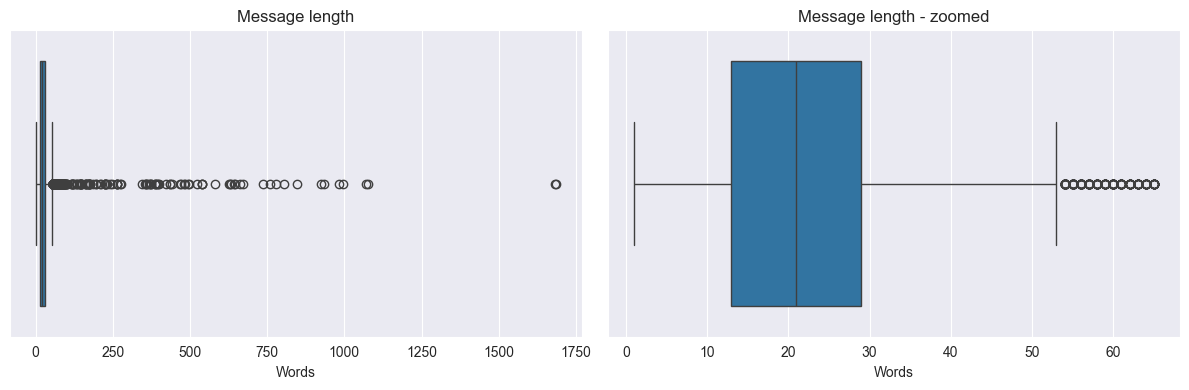

In [102]:
df_clean["msg_len"] = df_clean["message"].str.split().str.len()
p99 = df_clean["msg_len"].quantile(0.99)
short_df = df_clean[df_clean["msg_len"] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df_clean["msg_len"], ax=axes[0])
axes[0].set_title("Message length")
axes[0].set_xlabel("Words")

sns.boxplot(x=short_df["msg_len"], ax=axes[1])
axes[1].set_title("Message length - zoomed")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

In [103]:
word_stats = df_clean["msg_len"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])
word_stats

count    25228.000000
mean        24.044633
std         32.618801
min          1.000000
1%           5.000000
5%           7.000000
50%         21.000000
95%         44.000000
99%         65.000000
max       1686.000000
Name: msg_len, dtype: float64

This message-length analysis shows that most of the messages in the dataset are short - the average is 21 words, while 99% stay below 65 words. However, the boxplots clearly show that there are some extreme cases, such as completely empty messages (no words detected) and very long messages up to 1686 words. This clearly suggests that most messages in the dataset fall in a range of 5-65 words.

#### Detect the amount of extremely long and short messages
Do inspect extreme messages, I created two boolean masks - for those with at most 5 words and for those with at least 100 words. These cut-offs were based on the observed length range mentioned in the previous step, where most messages fall roughly between 5 and 65 words. Messages with at most 5 words are much smaller and could potentially not contain any valuable information, while messages with at least 100 words are way beyond the range limit and might be irrelevant for organizations like the Red Cross.

In [104]:
short_mask = df_clean["msg_len"] <=5
long_mask  = df_clean["msg_len"] >= 100
n_total = len(df_clean)
n_short = short_mask.sum()
n_long  = long_mask.sum()

print(f"Extremely short: {n_short}")
print(f"Extremely long: {n_long}")

Extremely short: 296
Extremely long: 102


The results show that there are 296 extremely short and 102 extremely long messages. To gain a better understanding of whether those messages are worth keeping, I will visually examine the samples. To ensure all informative messages are kept, I will first divide the short ones into 3 batches and manually inspect all of them:

In [105]:
pd.set_option("display.max_colwidth", None)
df_short = df_clean.loc[short_mask, ["id", "message"]].copy()
batch1 = df_short.iloc[0:101]
batch1

,id,message
5,14,Information about the National Palace-
350,425,"Need food, water and medicine"
417,520,self eplanatory. read text msg.
431,535,bandits who come to Port-au-prince
452,557,what cyber cafe's are working?
515,633,Graphic Designer - IT professional.
625,772,Simpaties to all haitian people
999,1202,which government office is working?
1082,1305,"Can you give something, please?"
1096,1320,Thank you for your understanding.


In [106]:
keep = [425,535, 1305, 1953, 2000, 2182, 2192, 3277, 3717, 4361, 5067, 5312, 5576, 6113, 6133, 6304, 6667, 6862, 7512]
batch2 = df_short.iloc[101:202]
batch2

,id,message
6814,7739,Where the social well-being is?
6840,7765,"today, how is the temperature?"
6888,7817,"Wy, chretian street no electricity."
6910,7841,this message does'nt means nothing.
6990,7922,This message is not important.
7055,7992,Information about Haiti rebuilt.
7059,7996,YOUR INFORMATION ABOUT TEMPERATURE.
7062,7999,Some information about the earthquake.
7117,8057,9GeQYeYGQEQtm
7237,8188,"earthquake tuesday January 12, 2010."


In [107]:
keep.extend([8336, 9464, 9561, 9564, 9576, 9695, 10044, 10053, 10136, 10186, 10508, 10563])
batch3 = df_short.iloc[202:303]
batch3

,id,message
9692,10942,What is the urgence information?
9764,11031,Robinson: 55 Ing Eliacin
9796,11076,"Health work, food, protection."
9837,11135,where the National Archives please
9945,11298,Earthquake just happened in Haiti
10384,11927,LoSoATM an earthquake un terremoto
10410,11961,theres an earthquake at haiti?
10635,12234,warm cloths and non-perishable food
10636,12235,"administrative , food distribution"
10679,12283,Power strips Toiletries Toilet paper


In [108]:
keep.extend([11076, 11298, 12234, 12235, 12365, 12379, 12748, 13041, 13633, 14238, 14301, 14405, 14405, 14494, 14591, 14615, 14623, 15675, 15794, 16261, 17182, 17752, 17853, 18229, 20304, 20354, 20822, 21048, 21661, 21799, 22020, 22361, 22413, 22456, 23277, 23382, 23450, 23592, 24627, 25062, 27395, 28072, 28650, 29775])
keep_ids = set(keep)
df_short_remove = df_short[~df_short["id"].isin(keep_ids)].copy()
df_clean = df_clean[~df_clean["id"].isin(df_short_remove["id"])].copy()
df_clean.shape

(25005, 8)

After manually inspecting all 303 message samples, I observed a lof non-informative messages asking for different kind of information and some gibberish that consisted of letters. These samples were remove from the final dataset. Messages requesting different types of needs and/or giving information about medical conditions and disasters were retained. Next, I will inspect the too long messages:

In [62]:
pd.set_option("display.max_colwidth", None)
df_long = df_clean.loc[long_mask, ["id", "message"]].copy()
df_long.sample(3)

,id,message
25668,29678,"Like that we want a fair representation at the regional level and district levels. The quakes flattened hundreds of houses, cracked more than 1,000 roads and triggered 11 fires, police and municipal officials said. The World Bank Group funds have been providing support to more than 18,000 schools as they have reopened, including through ensuring cleaning and sanitizing of schools, building or repairing handwashing stations and water points in schools, and training teachers to use thermometers. - access to pure drinking water;. But a meeting of members of Parliament geared toward naming a committee to choose a new speaker yesterday disintegrated into an all-out brawl of punching and kicking. Amnesty International also documented human rights violations committed against refugees by Kenyan security forces, including police abuse and forced returns to Somalia. This is the alternative route linking Maputo to parts of the country north of Xai Xai while the main national highway (EN1) remains impassable between Chicumbane and Xai Xai. The town has changed hands many times, each occasion bringing fresh allegations of civilian killings. In addition to items flown from Beira to Caia, then transported by road to Chupanga, five 4x4 trucks hired by the CVM, the Federation, and the Spanish Red Cross arrived in Chupanga from Beira a week ago. The ex-rebel combatants, on their side, acknowledged the harsh impact landmines and the conflict had left on their communities and recognized the usefulness of more enhanced cooperation with the authorities."""
20441,23831,"Cold weather, and the crowding which results, is associated with more opportunities for person-to-person transmission of respiratory pathogens. Critical supplies include antibiotics, analgesics, personal care items and feminine hygience products, anti-malarials, vitamins and nutritional supplements, cold and cough medicines, disposable gloves, burn creams, antithelmics, wound care supplies, vaccines oral rehydration solution, and sutures and surgical supplies. Coastline Trains Back on Track Soon: Trains will be back on track between Colombo and Matara in early March but will be subject to delays until a new signaling system is installed according to the local Sunday Observer. I have my basic tools but once I get a compressor, and a few more items I can employ two more people."
19967,23299,"We learned a lot during the recent influenza epidemics and before that from Hurricane Mitch, floods and landslides. Alternative water sources include open canals, which may harbour chemical contamination (river salt, pesticides and fertilisers) and pathogenic microbes from uncontrolled sewage disposal. In insecure areas we have to talk to everyone, each party regardless of their political or ideological position is a stakeholder and we have to get everyone aligned around one central theme-children and their wellbeing. More than 50,000 people have received treatment - many of them for gastro-intestinal ailments - in Pakistan Red Crescent health-care units in the north-western province of Khyber Pakhtunkhwa since the start of August. The 12 illnesses covered are: malignant tumors (including leukemia); organ and stem cell transplant; acute kidney failure; aplastic anemia; benign brain tumors; acute hepatitis; sequelae of cerebritis or meningitis; infantile paralysis; serious juvenile rheumatoid arthritis; serious Kawasaki disease; Myasthenia Gravis; and insulin-dependent diabetes mellitus. Nigeria specialist Marc-Antoine Perouse de Montclos, said the Boko Haram insurgency is not an inter-religious"" conflict pitting Muslims against Christians."


After inspecting the extremely long messages, I decided to keep them as they represent detailed crisis-related reports rather than noisy, non-informative long texts.

### Sample "Non-label" samples
After globally cleaning the dataset, I will sample perform quick data quality check by sampling the "non-label" messages. The goal is to confirm that these rows still provided crisis-related information and are not just random texts:

In [52]:
df_clean.drop(columns=["msg_len"], inplace=True)
label_count = df_clean[new_labels].sum(axis=1)
no_label_mask = label_count == 0
has_label_mask = label_count >= 1
df_clean.loc[no_label_mask, ["id", "message"]].sample(3)

,id,message
22404,25995,"Identifying the most vulnerable homeless families, Caritas plans to build 168 shelters - the portable, lattice-framed yurts traditionally used by nomadic Mongolians."
16555,19503,"For the last two weeks, an unprecedented army worm infestation has been reported from various districts in northern Liberia."
25973,30037,"BAMAKO/KIDAL, 7 August 2014 (IRIN) - Continued violence in northern Mali which saw three separatist rebel groups retake control of much of the north, has put peace talks set for August, and the July roadmap to peace signed by rebel groups and the Malian government, on shaky ground."


### Sample messages with labels
In this step, I will inspect some messages that contain at least one positive target variable. The goal is to confirm that these samples are valid crisis-help/need requests:

In [67]:
has_label_mask = label_count >= 1
df_clean.loc[has_label_mask, ["id", "message"]].sample(3)

,id,message
5293,6028,"We need help at Centre Dadadou, Delmas 3, such as a tent or tarp - we havent gotten any of those things - ad we are under water in the rain? - what can be done for us?"
8447,9481,"we're in souch street we don't find anybody come to give us help.we need all the things food,water and medical care thank you before"
18113,21245,"Rescuers piled bodies on the banks of the murky waterways, used mainly to drain industrial waste."


### Check dataset balance
After performing data quality cleaning, I will check the distribution between messages with and without labels to understand the final dataset imbalance and decide how to handle it properly:

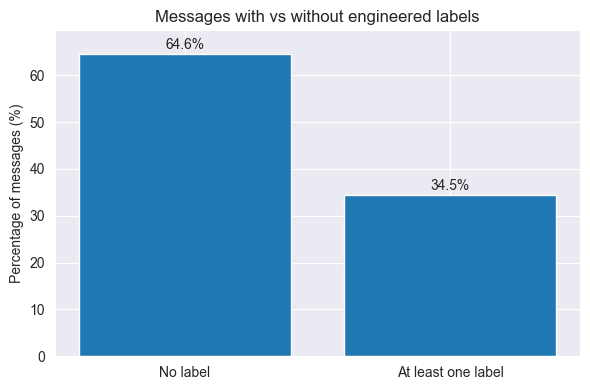

In [110]:
has_any_new = (df_clean[new_labels].sum(axis=1) > 0)
counts_new = has_any_new.value_counts().sort_index()
labels = ["No label", "At least one label"]
values_pct = [counts_new[False] / n_total * 100,counts_new[True] / n_total * 100]

plt.figure(figsize=(6, 4))
plt.bar(labels, values_pct)
plt.ylabel("Percentage of messages (%)")
plt.title("Messages with vs without engineered labels")
for i, v in enumerate(values_pct):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.ylim(0, max(values_pct) + 5)
plt.tight_layout()
plt.show()

The visualisation above compares the percentage of messages with and without labels. As we can see, more than 60% do not have any need-related labels, while slightly more than 30% has at least 1. This was already expected because of the already existing imbalance in the original dataset and the fact that the new engineered labels are more specific and only capture needs and people status. However, the ratio between no-labels vs labels (2:1) shows moderate imbalance. To reduce the dominance of "non-label" messages, I will apply undersampling technique on the training set.

## Extract small inference set
Before creating the train/val/test split, I will extract a small subset for inference testing and demonstrating the behaviour of the final model on completely unseen messages. In the code below, I split the dataset into 2 groups - with at least one positive label and without any labels to ensure diversity. Then, I randomly select 10 samples without any labels. Next, for each label in the dataset, I select all messages where this label is positive and randomly get 10 samples. Finally, I remove the selected samples from the main dataset and save them in the `final` folder:

In [116]:
df_with = df_clean[has_any_new].copy()
df_without = df_clean[~has_any_new].copy()
inf_without =  df_without.sample(n=min(10, len(df_without)), random_state=42)
infer_with_parts = []
for label in new_labels:
    candidates = df_with[df_with[label] == 1]
    n = min(10, len(candidates))
    if n > 0:
        infer_with_parts.append(candidates.sample(n=n, random_state=42))

infer_pos = pd.concat(infer_with_parts)
df_inference = pd.concat([inf_without, infer_pos])
df_model = df_clean.drop(index=df_inference.index).reset_index(drop=True)
df_inference.to_csv("../data/final/disaster_inference.csv", index=False)
df_model.to_csv("../data/final/disaster_dataset.csv", index=False)

print("Inference set:", df_inference.shape)
print("Modelling set:", df_model.shape)

Inference set: (60, 7)
Modelling set: (24946, 7)


## Feature selection
In this step, I select the *message* column as input feature for my models and the all remaining label columns as multi-label target. This step ensures that only relevant information is used for training.

In [9]:
from utilities import helper

feature = df_model["message"]
label_cols = helper.get_label_columns(df_model)

x = feature.copy()
y = df_model[label_cols].copy()

## Splitting into train/val/test sets
In this step, I split my data into three subsets - train (70%), validation (15%) and test (15%). First, I split the data into train/temporary subsets. Then, I split the temporary subset evenly into validation and test sets. I chose this separation as it will allow me to train and tune all models on the train/validation sets, while keeping the testing one completely unseen. Additionally, I use iterative stratification to ensure the proportions of all target labels, including the non-label messages are evenly distributed across the splits.Lastly, I print the number of rows in each set to verify that the split matches the intended ratio:

In [12]:
from skmultilearn.model_selection import iterative_train_test_split

X = x.to_numpy().reshape(-1, 1)
y = y.to_numpy()
X_train, y_train, X_temp, y_temp = iterative_train_test_split(X, y, test_size=0.30)
X_val, y_val, X_test, y_test = iterative_train_test_split(X_temp, y_temp, test_size=0.50)

print("Train:", X_train.shape[0])
print("Val:  ", X_val.shape[0])
print("Test: ", X_test.shape[0])

Train: 17462
Val:   3742
Test:  3742


#### Compare category proportions per split
In this step, I will check the target variables distribution across train, test and validation splits to confirm each split consists of equal examples per target and ensure fair unbiased evaluation:

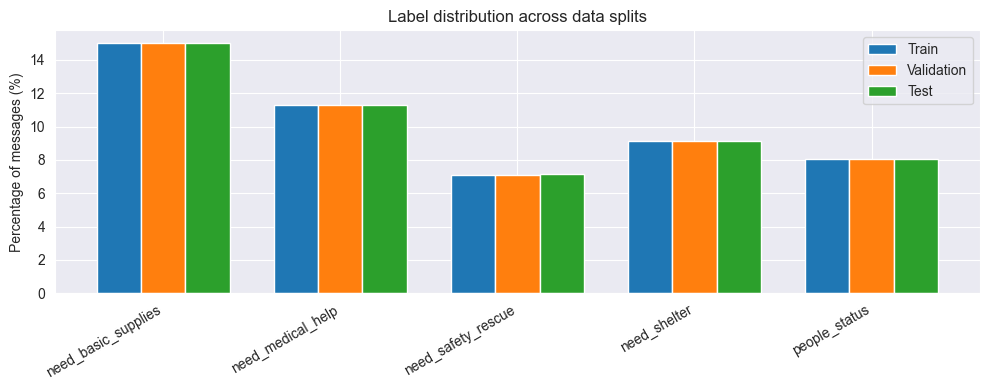

In [15]:
label_names = y.columns.tolist()
def plot_label_proportions_compare(y_train, y_val, y_test, label_names):
    train_p = y_train.mean(axis=0) * 100
    val_p   = y_val.mean(axis=0) * 100
    test_p  = y_test.mean(axis=0) * 100

    x = np.arange(len(label_names))
    w = 0.25

    plt.figure(figsize=(10,4))
    plt.bar(x - w, train_p, width=w, label="Train")
    plt.bar(x,     val_p,   width=w, label="Validation")
    plt.bar(x + w, test_p,  width=w, label="Test")

    plt.xticks(x, label_names, rotation=30, ha="right")
    plt.ylabel("Percentage of messages (%)")
    plt.title("Label distribution across data splits")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_label_proportions_compare(y_train, y_val, y_test,label_names)

The chart above compares the percentage of messages containing each label across the train, test and validations splits. It confirms that the splitting strategy was applied properly and preserved the label proportions.

#### Dataset balance before undersampling (train set)
In this step, I will inspect the label vs non-label distribution in the train set before applying undersampling, to ensure the stratification in the previous step was properly applied:

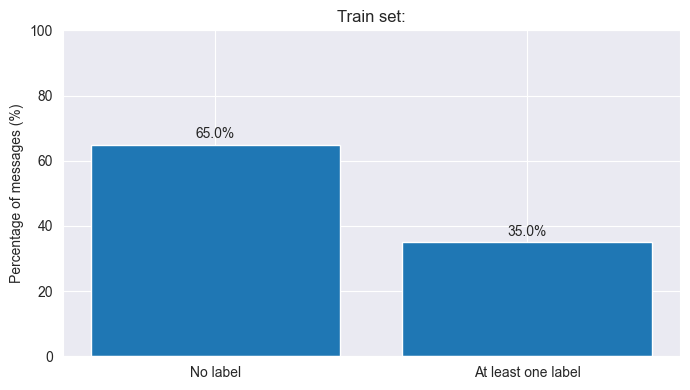

In [13]:
import numpy as np
import matplotlib.pyplot as plt

has_any_train = (y_train.sum(axis=1) > 0).astype(int)

no_label = (has_any_train == 0).sum()
has_label = (has_any_train == 1).sum()
total = no_label + has_label

vals = [100 * no_label / total, 100 * has_label / total]
catt = ["No label", "At least one label"]

plt.figure(figsize=(7,4))
bars = plt.bar(catt, vals)
plt.title("Train set:")
plt.ylabel("Percentage of messages (%)")
plt.ylim(0, 100)
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

The bar chart above confirms that the non-label vs label proportions were properly preserved in the splitting step - the ratio remains 2:1. To prevent introducing bias towards the non-label category during training, in this iteration I will apply undersampling on the training set.

#### Undersampling train set
In this step, I select the indices of all both messages with at least 1 label and messages with 0 labels. Then, I randomly remove a set of the non-label samples so its size matches the size of the positive samples. Finally, I combine and shuffle all indices that will be kept. The undersampling is applied only on the train set to reduce majority-class bias during training, while test and validation splits remain untouched to reflect the real-world message distribution.

In [17]:
pos_idx = np.where(has_any_train == 1)[0]
neg_idx = np.where(has_any_train == 0)[0]
rng = np.random.default_rng(42)
neg_keep = rng.choice(neg_idx, size=len(pos_idx), replace=False)

keep_idx = np.concatenate([pos_idx, neg_keep])
rng.shuffle(keep_idx)
X_train_us = X_train[keep_idx]
y_train_us = y_train[keep_idx]
has_any_train_us = has_any_train[keep_idx]

#### Dataset balance after undersampling (train set)

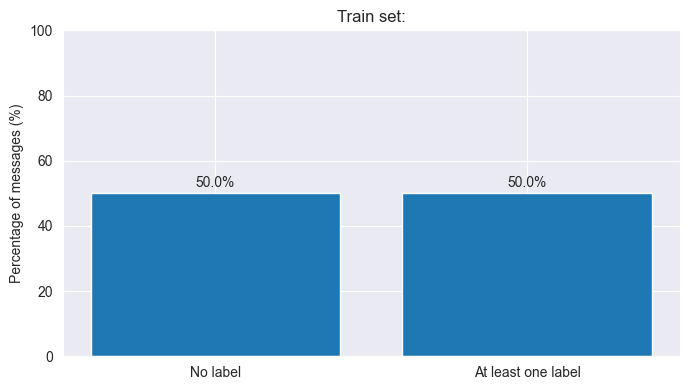

In [18]:
a = np.asarray(has_any_train_us).astype(int)
no_label = (a == 0).sum()
has_label = (a >= 1).sum()
total = no_label + has_label
vals = [100 * no_label / total, 100 * has_label / total]
catt = ["No label", "At least one label"]

plt.figure(figsize=(7,4))
bars = plt.bar(catt, vals)
plt.title("Train set:")
plt.ylabel("Percentage of messages (%)")
plt.ylim(0, 100)

for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

The bar chart above confirms that the undersampling was properly applied. The size of the two categories is now balanced with 50% non-label messages and 50% positive messages.

#### Save train/val/test sets
This step is very important, as it ensures the consistency and reproducibility across all models. The subsets are saved in separate files so that each model can use the exactly same input data during training, validation and evaluation.

In [122]:
X_train_us.to_csv("../data/split_data/X_train.csv", index=False)
X_val.to_csv("../data/split_data/X_val.csv", index=False)
X_test.to_csv("../data/split_data/X_test.csv", index=False)

y_train_us.to_csv("../data/split_data/y_train.csv", index=False)
y_val.to_csv("../data/split_data/y_val.csv", index=False)
y_test.to_csv("../data/split_data/y_test.csv", index=False)

## Text normalization
#### Converting to lowercase
The first step in the text normalization phase is to lowercase all messages. This is an important step that ensures all words with different capitalization patterns are treated as the same token. It also makes the TF-IDF representation more compact and consistent.

**Example:**
Without lowercasing, the 3 different versions of "water" would be treated as different tokens.
*Before lowercasing:* "water", "Water", "WATER"
*After lowercasing:* "water"

In [133]:
pd.set_option("display.max_colwidth", None)
messages = X_train_us.astype(str).copy()
lowered_messages = messages.str.lower()

df = pd.DataFrame({"original": messages, "lowercased": lowered_messages})
df.sample(3)

,original,lowercased
1122,China has said 5.47 million people were made homeless by the May 12 quake and more than 11 million people were expected to be housed in camps as areas rendered unlivable were evacuated.,china has said 5.47 million people were made homeless by the may 12 quake and more than 11 million people were expected to be housed in camps as areas rendered unlivable were evacuated.
8739,That's not to the american people to tell us what we must do. Ok!,that's not to the american people to tell us what we must do. ok!
10104,RT CAREAustralia 7.0 earthquake has struck Haiti one of the world s poorest countries. Impact will be devastating. http ow.ly VSR2,rt careaustralia 7.0 earthquake has struck haiti one of the world s poorest countries. impact will be devastating. http ow.ly vsr2


#### Replacing URLs and email addresses
Some messages in the dataset, contain URLs and email addresses, for references to news articles or contact details. Usually, they are not relevant for the model and can be removed completely from the sentence to reduce noise, vocabulary size and help the model focus on the more important parts of the sentence:

In [134]:
msg = df["lowercased"]
url_norm = msg.str.replace(r"http\S+|www\.\S+", " ", regex=True)
email_norm = url_norm.str.replace(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " ", regex=True)
changed_mask = msg.ne(email_norm)
df_examples = pd.DataFrame({"original":msg.loc[changed_mask], "after_url_email_replacement": email_norm.loc[changed_mask]})
df_examples.sample(3)

,original,after_url_email_replacement
11947,"chile rushes troops, aid to quake-stricken towns: concepcion, chile (reuters) - looters raided more stores in this.. http://bit.ly/ch49ux","chile rushes troops, aid to quake-stricken towns: concepcion, chile (reuters) - looters raided more stores in this.."
8113,storm claims at least 22 lives; subway service and full power are days away from being restored http://t.co/fnb5v2sw via @sharethis,storm claims at least 22 lives; subway service and full power are days away from being restored via @sharethis
11527,the family was driving along this road just the other week. http://bit.ly/bg1atr. this will cause chaos travelling around santiago.,the family was driving along this road just the other week. this will cause chaos travelling around santiago.


#### Handling hashtags and user mentions
Some messages come from social media, which is why they might contain hashtags and user mentions, as in some of the samples above. In this project, they are considered not informative and will be handled similarly to the URLs and emails:

In [135]:
msg = email_norm.copy()
hashtag_norm = msg.str.replace(r"#(\w+)", " ", regex=True)
mention_norm = hashtag_norm.str.replace(r"@\w+", " ", regex=True)
changed_mask = msg.ne(mention_norm)
df_example = pd.DataFrame({"original": msg.loc[changed_mask],"after_hashtag_mention_handling": mention_norm.loc[changed_mask]})
df_example.sample(3)

,original,after_hashtag_mention_handling
2947,"rt pacetesix15: #chile needs fund relief, imagine?! rt @wiredscience: chile quake moved the city of concepcion 10 feet to the west. ht ..","rt pacetesix15: needs fund relief, imagine?! rt : chile quake moved the city of concepcion 10 feet to the west. ht .."
8274,just saw pictures of my breezy house and lost it #fuckyousandy #wantlifebacm,just saw pictures of my breezy house and lost it
3556,cabs not taking in passengers in fear of long lines at gas stations before shift change #nyc @nycitylens #sandy,cabs not taking in passengers in fear of long lines at gas stations before shift change


#### Clean up punctuation and whitespace
In this step, I reduce the noise and vocabulary size by collapsing repeated punctuation into one symbol. Additionally, I normalize whitespaces by replacing any extra tabs or new lines with a single space and removing any space in the beginning or end of the message.

**Punctuation example:**
- Raw: !!!
- Normalized: !

In [136]:
msg = mention_norm.copy()
punc_norm = msg.str.replace(r"([!?.,])\1{1,}", r"\1", regex=True)
space_norm = punc_norm.str.replace(r"\s+", " ", regex=True).str.strip()
changed = msg.ne(space_norm)
df_example = pd.DataFrame({"original": msg.loc[changed_mask],"after_punctuation_whitespace_handling": space_norm.loc[changed_mask]})
df_example.sample(3)

,original,after_punctuation_whitespace_handling
6013,new yorkers : come volunteer w/ us on les at 46 hestor 10 am . delivering meds to elderly still in highrises being flashlight .,new yorkers : come volunteer w/ us on les at 46 hestor 10 am . delivering meds to elderly still in highrises being flashlight .
10443,"no rain yet but plenty of wind. ready as we'll ever be. police have all entries to downtown highlands blocked off.ugh leaving my apartment to go into the unknown.. they better allow us back here! im freaking the fuck out!!! go away that's a hell of a storm surge! not seeing much here in the city yet. stay safe! wondering how many babies in new york will be called in 9 months time i love how in the midst of a hurricane, your hair looks dry! lol","no rain yet but plenty of wind. ready as we'll ever be. police have all entries to downtown highlands blocked off.ugh leaving my apartment to go into the unknown. they better allow us back here! im freaking the fuck out! go away that's a hell of a storm surge! not seeing much here in the city yet. stay safe! wondering how many babies in new york will be called in 9 months time i love how in the midst of a hurricane, your hair looks dry! lol"
1914,"we living in the national school ,we waiting your help such as : food,water,tent. thank you,i wait your help.","we living in the national school ,we waiting your help such as : food,water,tent. thank you,i wait your help."


#### Lemmatization
As a last text normalization step, I will apply lemmatization. This technique is used to reduce words to their base or dictionary form to ensure words with similar meanings are treated the same. In this project, I decided to use "spaCy", as it gives accurate part-of-speech-aware lemmas (can distinguish verbs from adjectives, etc.) and works fast.
<p style="text-align: center;">
  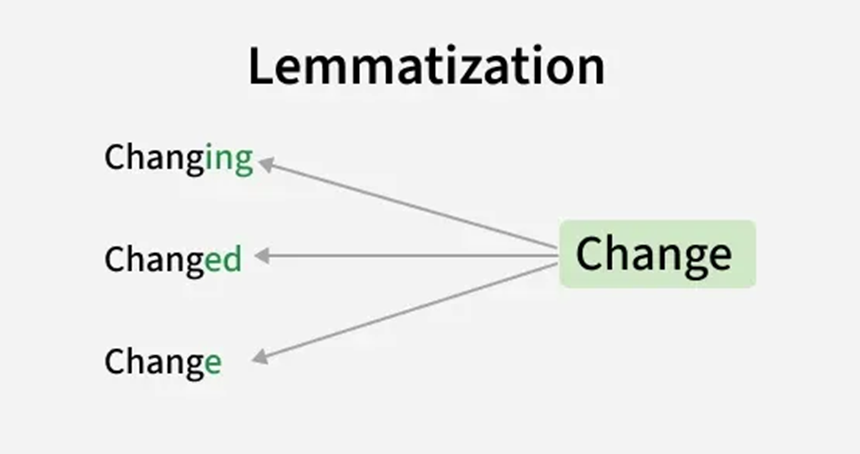
</p>
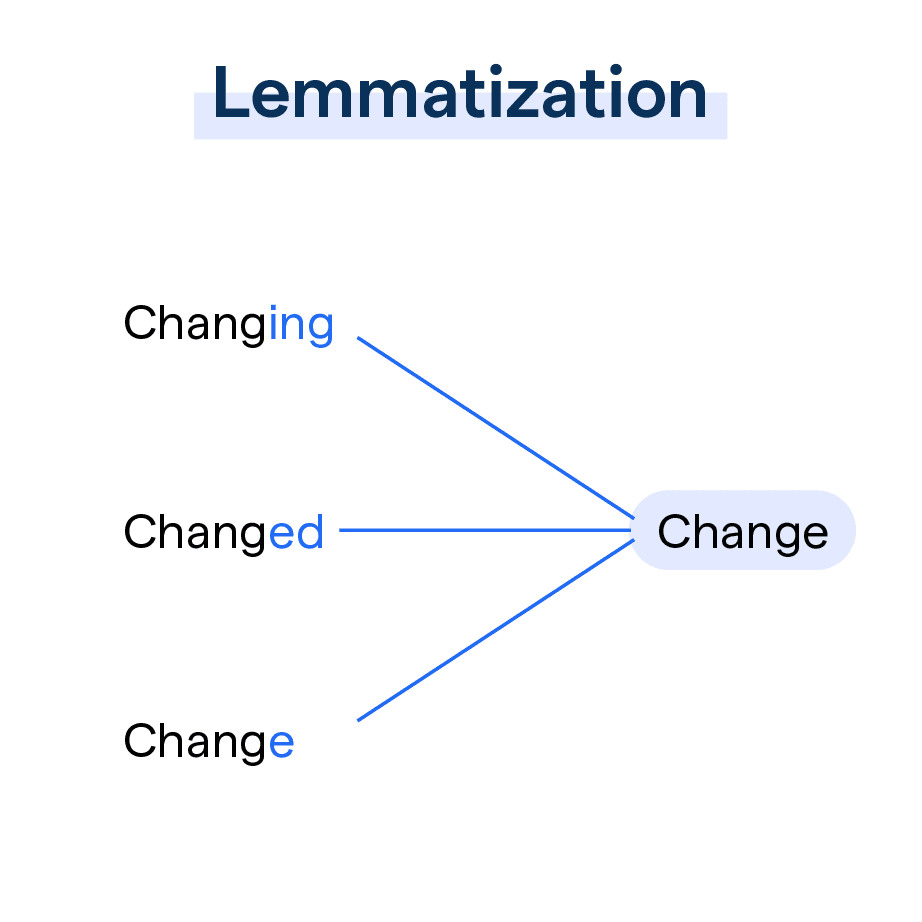
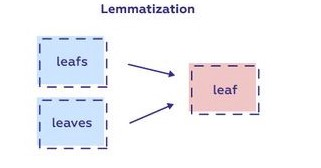

In [137]:
import spacy

def lemmatize_text(text):
    keep = {"no", "not", "never", "n't"}
    doc = nlp(text)
    lemmas = []
    for token in doc:
        if token.ent_type_ in ("GPE", "LOC", "FAC"):
            continue
        if token.is_space or token.is_punct:
            continue
        if token.is_stop and token.text.lower() not in keep:
            continue
        lemmas.append(token.lemma_.lower())
    return " ".join(lemmas)

nlp = spacy.load("en_core_web_sm")
ex_lem = df_example["after_punctuation_whitespace_handling"].copy()
examples_lem_norm = ex_lem.apply(lemmatize_text)
df_lem = pd.DataFrame({"original": ex_lem.values,"lemmatization": examples_lem_norm.values})
df_lem.head()

,original,lemmatization
0,is doing a sneaker drive for those who lost theirs durring sandy and have competition coming up! all sizes! _,sneaker drive lose theirs durre sandy competition come size
1,*praise dance through the house* powers back betches! it out with . glad we dug our roots into cali soil because they're all uprooted in this city! never seen nyc like this b4,praise dance house power betche glad dig root cali soil uproot city never see nyc like b4
2,first episode of homeland in . not sure what made me more tense . that or sandy 's winds .,episode homeland not sure tense sandy wind
3,ihanna please rt please help this goes to staten islanders directnext hurricane better be named nipples tooty-fruity. can't really be afraid of that much.2am gas line heights,ihanna rt help go staten islander directnext hurricane well name nipple tooty fruity not afraid much.2am gas line height
4,new york awakes to sandy's destruction most read by neighbors in,awake sandy destruction read neighbor


To lemmatize the messages in the dataset, I created the `lemmatize_text` function, which uses the loaded English spaCy model to extract lemmatized tokens from the passed texts, while skipping spaces, so they are not counted as separate words. Additionally, tokens recognised as location entities (GPE, LOC, FAC) are also being skipped and stop words - frequent function words, different from the ones in the keep list are being removed.  For all normal words, it takes their base forms and adds them to the list. Lastly, all lemmas are joined with spaces and return as a single string.

#### Vocabulary reduction
To understand how the text normalization and lemmatization affects the vocabulary size, I will compare the amount of all unique tokens before and after applying normalization:

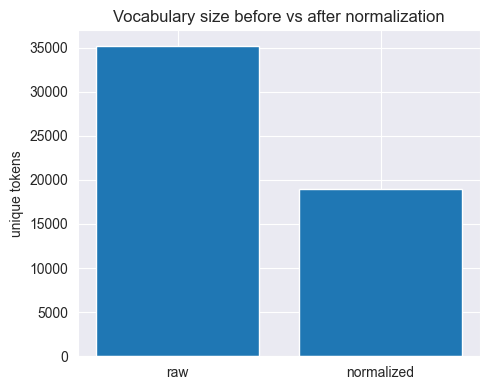

In [142]:
raw_tokens = msg.str.lower().str.split()
lem_tokens = msg.apply(lambda t: preprocess_text(str(t))).str.split()
raw_vocab = set(tok for lst in raw_tokens for tok in lst)
lem_vocab = set(tok for lst in lem_tokens for tok in lst)

plt.figure(figsize=(5,4))
plt.bar(["raw", "normalized"], [len(raw_vocab), len(lem_vocab)])
plt.title("Vocabulary size before vs after normalization")
plt.ylabel("unique tokens")
plt.tight_layout()
plt.show()

The chart above compares the vocabulary size before and after normalization and lemmatization. The raw vocabulary consists of around 35 000 unique tokens, while the normalized one was significantly reduced to less than 20 000. This reduction is partly due to the removal of unnecessary tokens such as URLs, mentions, hashtags, emails and locations and the removal of stop words. Additionally, this also indicates that a lot of words were reduced to their base form in the lemmatization step.

In [1]:
import pandas as pd

X_train_us = pd.read_csv("../data/split_data/X_train.csv")
y_train = pd.read_csv("../data/split_data/y_train.csv")

## Term Frequency - Inverse Document Frequency
TF-IDF is a statistical method used in natural language preprocessing to measure how important a word is.
 - *Term Frequency* - measures how important a word is in a message; the more the word appear, the greater importance it has
 - *Inverse Document Frequency* - measures how rare a word is across all given messages

The final weight is based on the terms above -  the more frequently a word appears in a message and the least frequently it appears across the whole dataset, the higher its final TF-IDF will be. In the example below, I use the small dataset with lemmatized samples to show how TF-IDF works. First, I fit the vectorizer on the training set, so it can learn which tokens appears often and assess how rare it is. Then, I select one message and extract its TF-IDF vector results. I filter the samples with non-zero weights. Lastly, I sort the top 10 weights, starting from the most important one and show the raw message:

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from utilities.text_normalization import preprocess_text

vec = TfidfVectorizer(preprocessor=preprocess_text, tokenizer=str.split,token_pattern=None,ngram_range=(1, 1),min_df=2,max_df=0.95,sublinear_tf=True)
X_tfidf = vec.fit_transform(X_train_us["message"])
feature_names = vec.get_feature_names_out()
raw = X_train_us["message"].iloc[18]
row = X_tfidf[18]
df_show = pd.DataFrame({
    "token_or_ngram": feature_names[row.indices],
    "feature_index": row.indices,
    "tfidf_weight": row.data.round(2)
}).sort_values("tfidf_weight", ascending=False)

print("Original message:\n", raw)
df_show.head(10)

Original message:
 Suffering the consequences are the people who are unable to receive the care they need: malaria, typhus, infections and surgical emergencies continue to be a daily problem for the population which, however, is no longer able to find any kind of assistance in the public health facilities.


,token_or_ngram,feature_index,tfidf_weight
5,consequence,1882,0.28
11,surgical,7252,0.28
6,unable,7735,0.27
13,daily,2145,0.24
19,kind,4233,0.24
17,able,486,0.23
9,malaria,4577,0.22
10,infection,3878,0.22
21,public,5947,0.21
4,suffer,7196,0.20


### Most label-indicative words
In this step, I will analyse which tokens are strongly associated with each target variable. To measure the strength with which each word contributes to the target, I will use the chi-square test. Tokens with higher score are considered helpful for distinguishing the target variables. For each label, I visualise the top 10 most useful tokens to understand what vocabulary drives each target and valdate the learned patterns:

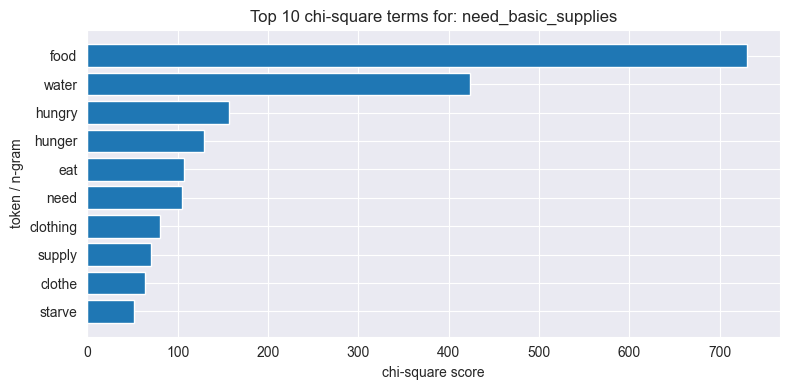

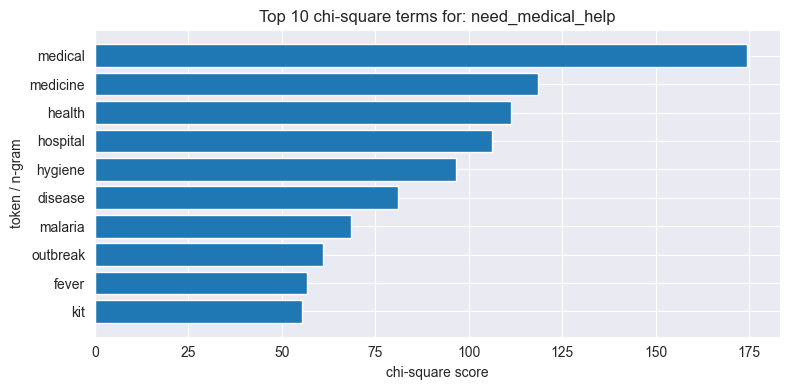

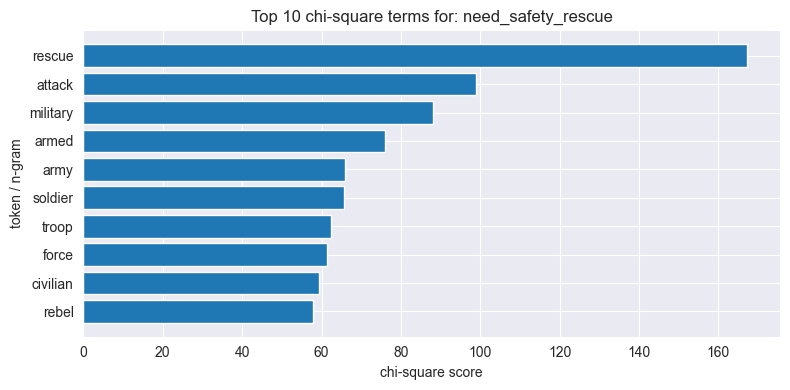

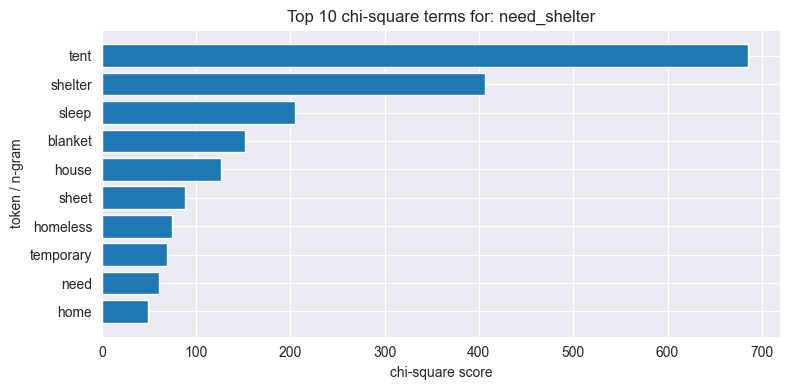

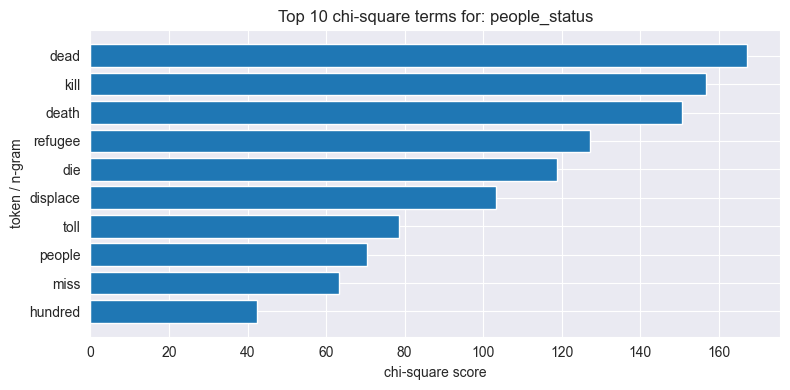

In [7]:
from sklearn.feature_selection import chi2
import numpy as np
import matplotlib.pyplot as plt

Y = y_train.copy()
label_cols = Y.columns.tolist()

def top_terms_chi2(label, k=20):
    y = Y[label].values
    chi, _ = chi2(X_tfidf, y)
    top_idx = np.argsort(chi)[-k:][::-1]
    return pd.DataFrame({"token_or_ngram": feature_names[top_idx],"chi2": chi[top_idx]})

for lab in label_cols:
    df_top = top_terms_chi2(lab, k=10).sort_values("chi2", ascending=True)

    plt.figure(figsize=(8,4))
    plt.barh(df_top["token_or_ngram"], df_top["chi2"])
    plt.title(f"Top {10} chi-square terms for: {lab}")
    plt.xlabel("chi-square score")
    plt.ylabel("token / n-gram")
    plt.tight_layout()
    plt.show()

The five graphs above show the most strongly associated words with each target variable. The results confirm that each token is aligned with the domain of the specific target variable:
 - need_basic_supplies is dominated by the words food, water, clothing and hunger
 - need_medical_help is dominated by clear healthcare vocabulary - medical, medicine, health, hospital, etc.
 - need_safety_rescue is driven by terms related to conflicts and protection such as rescue, attack, military, armed, etc.
 - need_shelter is strongly tied with words related to housing and temporary living - tent, shelter, homeless, etc.
 - people_status is connected to terms describing casualties and displacement - dead, kill, death, refugees, displace, etc.

#### Assess how discriminative each target variable is
In this step, I will check how distinguishable each target variable is. In order to do so, I will use the chi-square results and check how many strongly-associated tokens appear for each target to understand which labels are harder to distingush:

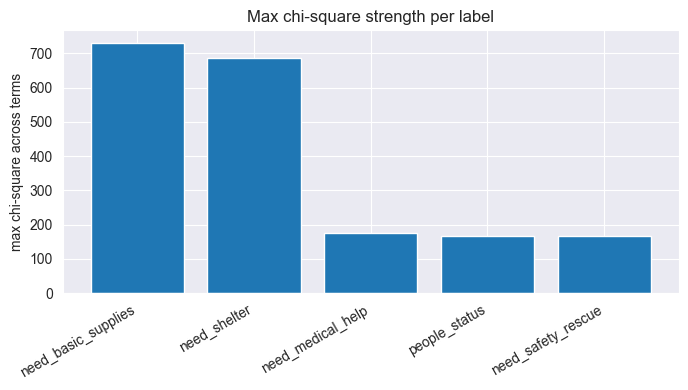

In [9]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2

max_chi = {}
for lab in label_cols:
    chi, _ = chi2(X_tfidf, Y[lab].values)
    max_chi[lab] = chi.max()

s = pd.Series(max_chi).sort_values(ascending=False)
plt.figure(figsize=(7,4))
plt.bar(s.index, s.values)
plt.title("Max chi-square strength per label")
plt.ylabel("max chi-square across terms")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The diagram indicates that *need_basic_supplies* and *need_shelter* have stronger signal than the other targets. This suggests that *need_medical_help, people_status* and *need_safety* are less dominated by a single distinctive word and may require combining multiple terms for more accurate predictions.

## Token - Lemma Cross Connection
### Check vocabulary compression
In this step, I create 2 versions of the messages in the training set using the *preprocess_text* function in my text normalization file. The token version keeps the normalized word forms as they are in the message. The lemma version keeps the converted base forms of the words - the word forms after lemmatization. For each version, I compute the vocabulary size by joining the preprocessed texts into one string and counting the unique terms per version. Finally, I calculate the vocabulary compression to check how much the vocabulary shrinks after using lemmatization:

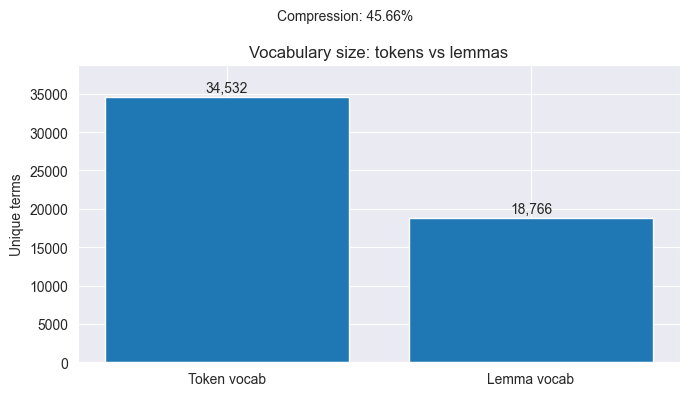

In [15]:
from collections import Counter

text_tok = X_train_us["message"].apply(lambda x: preprocess_text(x, lemmatize=False))
text_lem = X_train_us["message"].apply(lambda x: preprocess_text(x, lemmatize=True))
tok_vocab = len(Counter(" ".join(text_tok).split()))
lem_vocab = len(Counter(" ".join(text_lem).split()))
compression = 100 * (1 - lem_vocab / max(tok_vocab, 1))

plt.figure(figsize=(7,4))
bars = plt.bar(["Token vocab", "Lemma vocab"], [tok_vocab, lem_vocab])
plt.title("Vocabulary size: tokens vs lemmas")
plt.ylabel("Unique terms")
plt.suptitle(f"Compression: {compression:.2f}%", y=0.98, fontsize=10)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + max(tok_vocab, lem_vocab)*0.01,f"{int(h):,}", ha="center", va="bottom")
plt.ylim(0, max(tok_vocab, lem_vocab) * 1.12)
plt.tight_layout()
plt.show()

The token-based vocabulary representation consists of 34 532 unique terms, while the lemma-based one consists of 18 766. The results show that the reduction is equal to almost half of the vocabulary size before lemmatization - 45.66%. The compression indicates that many words differ mainly by inflection. Reducing the vocabulary size should improve models' generalization across different variations of the same word.

### Check distribution of token forms per lemma
In this step, I measure how many tokens map to the same lemma. First, I lemmatize the token-based version and build a dictionary that contains all lemmas and all unique tokens, that were transformed into the specific lemma. Next, I visualise the distribution through a histogram:
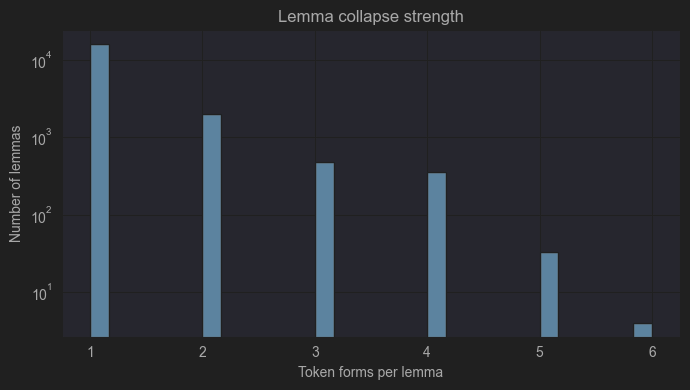

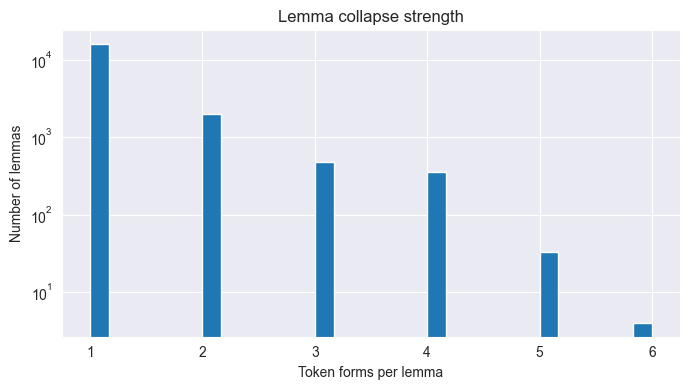

In [37]:
from collections import defaultdict
from utilities.text_normalization import get_nlp
import pandas as pd

nlp = get_nlp()
extra = {"however", "also", "therefore", "moreover", "thus"}
keep = {"no", "not", "never", "n't"}
lemma_to_tokens = defaultdict(set)
for doc in nlp.pipe(text_tok, batch_size=256):
    for t in doc:
        if t.ent_type_ in ("GPE", "LOC", "FAC"):
            continue
        if t.is_space or t.is_punct:
            continue
        if (t.is_stop and t.text.lower() not in keep) or (t.text.lower() in extra):
            continue
        lemma_to_tokens[t.lemma_.lower()].add(t.text.lower())

sizes = np.array([len(s) for s in lemma_to_tokens.values()])
plt.figure(figsize=(7,4))
plt.hist(sizes, bins=30)
plt.yscale("log")
plt.title("Lemma collapse strength")
plt.xlabel("Token forms per lemma")
plt.ylabel("Number of lemmas")
plt.tight_layout()
plt.show()

The bar chart above shows that the majority of the lemmas correspond to exactly 1 token from, which means that the reduction is dominated by one-to-one mappings. As the number of forms per lemma gets bigger the number of lemmas get lower. This indicates that only a small subset of lemmas absorbs multiple tokens variants.

### Check lemmas with most token forms
In this step, I  identify which are the 15 top lemmas that absorbed the most tokens to understand which lemmas have higher impact on the vocabulary reduction:

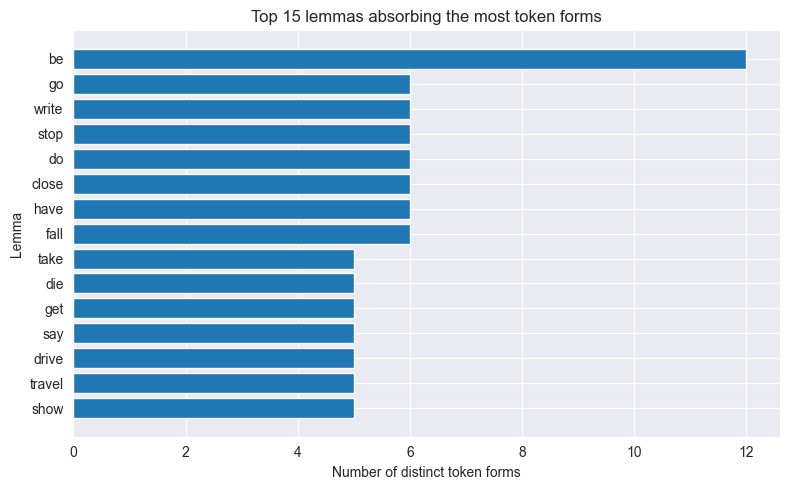

be: 'm, 're, 's, ai, am, are, be, been, being, is, was, were
go: go, goes, going, gon, gone, went
write: write, writed, writes, writing, written, wrote
stop: stop, stoped, stoping, stopped, stopping, stops
do: did, do, does, doing, done, dos


In [30]:
df_collapse = (pd.DataFrame({"lemma": list(lemma_to_tokens.keys()),"n_token_forms": [len(s) for s in lemma_to_tokens.values()]}).sort_values("n_token_forms", ascending=False).reset_index(drop=True))
top = df_collapse.head(15).iloc[::-1]

plt.figure(figsize=(8,5))
plt.barh(top["lemma"], top["n_token_forms"])
plt.title(f"Top {15} lemmas absorbing the most token forms")
plt.xlabel("Number of distinct token forms")
plt.ylabel("Lemma")
plt.tight_layout()
plt.show()

top5 = df_collapse.head(5)["lemma"].tolist()
for lem in top5:
    forms = sorted(list(lemma_to_tokens[lem]))[:12]
    print(f"{lem}: {', '.join(forms)}")

The results above show that the top 15 most absorbing lemmas are *be, go, write, stop, do, close, have, fall, take, die, get, say, drive, travel* and *show*. The most common one is *"be"* with 12 different token forms. The next 7 lemmas consist of 6 different tokens and the last 7 consist of 5. The examples of lemma-token pairs confirms that the lemmatization mainly reduces vocabulary by merging tense variations of verbs rather than merging unrelated words.

### Check tokens mapping to multiple lemmas
In this step, I check if a token can be lemmatized into different lemmas in different contexts. If a token has more than one lemma, it is considered ambiguous - its meaning or grammatical role changes depending on the context of the sentence. This step is important as it shows a possible limitation of lemmatization - some tokens might be ambiguous and introduce noise:

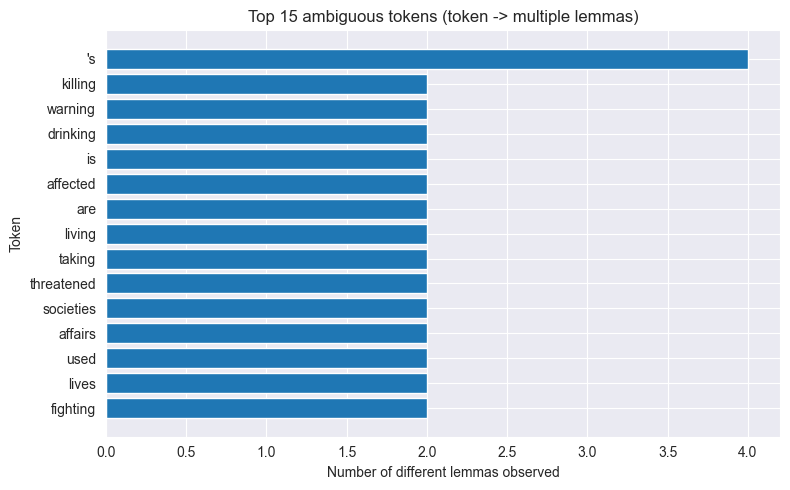

In [31]:
token_to_lemmas = defaultdict(set)
for doc in nlp.pipe(text_tok, batch_size=256):
    for t in doc:
        if t.is_space or t.is_punct:
            continue
        token_to_lemmas[t.text.lower()].add(t.lemma_.lower())

df_amb = (pd.DataFrame({"token": list(token_to_lemmas.keys()),"n_lemmas": [len(s) for s in token_to_lemmas.values()]})
    .query("n_lemmas >= 2")
    .sort_values("n_lemmas", ascending=False)
    .reset_index(drop=True)
)
top = df_amb.head(15).iloc[::-1]
plt.figure(figsize=(8,5))
plt.barh(top["token"], top["n_lemmas"])
plt.title(f"Top {15} ambiguous tokens (token -> multiple lemmas)")
plt.xlabel("Number of different lemmas observed")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

In [23]:
for tok in df_amb.head(10)["token"]:
    lems = sorted(list(token_to_lemmas[tok]))
    print(f"{tok} -> {lems}")

's -> ["'", "'s", 'be', 'us']
killing -> ['kill', 'killing']
warning -> ['warn', 'warning']
drinking -> ['drink', 'drinking']
is -> ['be', 'is']
affected -> ['affect', 'affected']
are -> ['are', 'be']
living -> ['live', 'living']
taking -> ['take', 'taking']
threatened -> ['threaten', 'threatened']


The results above confirm that there is a fraction of ambiguous tokens confirming that lemmatization is consistent but not always perfect. In this dataset, the top 15 ambiguous tokens are *'s* which has 4 different lemmas. Other tokens such as *killing, warning, drinking, is, etc.* have only 2 lemmas. Overall, the results show that ambiguity does not have a major impact on the vocabulary reduction.